# Experimenting with Regression Models
## Simple Linear Regression
#### Goal: Predict CO2 Emissions (g/km) using a single predictor like Engine Size (L).
#### Insight: This helps you visualize the basic direct relationship where larger engines generally lead to higher emissions.

## Multiple Linear Regression
#### Goal: Predict emissions using multiple independent variables such as Engine Size, Cylinders, and Fuel Consumption (Combined L/100 km).
#### Insight: This captures how different mechanical factors work together to influence the total carbon footprint, typically providing a higher score than the simple model.

## Polynomial Regression
#### Goal: Model "curvier" or non-linear trends between variables like Fuel Consumption and CO2 Emissions.
#### Insight: Real-world data often shows that as fuel consumption increases, emissions may rise at a non-proportional rate. Adding polynomial features (like or) allows the model to fit these curves more accurately. 

In [232]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import scipy.stats as stats

%matplotlib inline  

from scipy import stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import ElasticNet, ElasticNetCV

from sklearn.model_selection import cross_val_score, cross_validate

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


import warnings


df=pd.read_csv("./datasets/co2.csv")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   str    
 1   Model                             7385 non-null   str    
 2   Vehicle Class                     7385 non-null   str    
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   str    
 6   Fuel Type                         7385 non-null   str    
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), in

In [233]:
df.shape
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [234]:
df.sample(5)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
6308,PORSCHE,911 Carrera GTS,MINICOMPACT,3.0,6,AM7,Z,11.5,9.1,10.4,27,243
3271,VOLKSWAGEN,GOLF SPORTWAGON,STATION WAGON - SMALL,1.8,4,M5,X,9.5,6.6,8.2,34,192
3215,TOYOTA,CAMRY,MID-SIZE,2.5,4,AS6,X,9.4,6.7,8.2,34,192
4377,ACURA,RLX HYBRID,MID-SIZE,3.5,6,AM7,Z,8.4,8.2,8.4,34,196
520,HYUNDAI,TUCSON 4WD,SUV - SMALL,2.0,4,A6,X,11.4,9.3,10.5,27,242


In [235]:
missing_count = df.isnull().sum()
value_count = df.isnull().count()
missing_percentage = round(missing_count / value_count * 100, 2)
missing_df = pd.DataFrame({"count": missing_count, "percentage": missing_percentage})
missing_df

,count,percentage
Make,0,0.0
Model,0,0.0
Vehicle Class,0,0.0
Engine Size(L),0,0.0
Cylinders,0,0.0
Transmission,0,0.0
Fuel Type,0,0.0
Fuel Consumption City (L/100 km),0,0.0
Fuel Consumption Hwy (L/100 km),0,0.0
Fuel Consumption Comb (L/100 km),0,0.0


In [236]:
# Check out the duplicated values!!!!!!!!

df.duplicated().sum()

np.int64(1103)

In [237]:
duplicated_rows = df[df.duplicated(keep=False)]

duplicated_rows

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
12,ALFA ROMEO,4C,TWO-SEATER,1.8,4,AM6,Z,9.7,6.9,8.4,34,193
13,ASTON MARTIN,DB9,MINICOMPACT,5.9,12,A6,Z,18.0,12.6,15.6,18,359
15,ASTON MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,AM7,Z,17.4,11.3,14.7,19,338
...,...,...,...,...,...,...,...,...,...,...,...,...
7356,TOYOTA,Tundra,PICKUP TRUCK - STANDARD,5.7,8,AS6,X,17.7,13.6,15.9,18,371
7365,VOLKSWAGEN,Golf GTI,COMPACT,2.0,4,M6,X,9.8,7.3,8.7,32,203
7366,VOLKSWAGEN,Jetta,COMPACT,1.4,4,AS8,X,7.8,5.9,7.0,40,162
7367,VOLKSWAGEN,Jetta,COMPACT,1.4,4,M6,X,7.9,5.9,7.0,40,163


In [238]:
# Let's observe unique values 

def get_unique_values(df):
    
    output_data = []

    for col in df.columns:

        # If the number of unique values in the column is less than or equal to 5
        if df.loc[:, col].nunique() <= 10:
            # Get the unique values in the column
            unique_values = df.loc[:, col].unique()
            # Append the column name, number of unique values, unique values, and data type to the output data
            output_data.append([col, df.loc[:, col].nunique(), unique_values, df.loc[:, col].dtype])
        else:
            # Otherwise, append only the column name, number of unique values, and data type to the output data
            output_data.append([col, df.loc[:, col].nunique(),"-", df.loc[:, col].dtype])

    output_df = pd.DataFrame(output_data, columns=['Column Name', 'Number of Unique Values', ' Unique Values ', 'Data Type'])

    return output_df

In [239]:
get_unique_values(df)

,Column Name,Number of Unique Values,Unique Values,Data Type
0,Make,42,-,str
1,Model,2053,-,str
2,Vehicle Class,16,-,str
3,Engine Size(L),51,-,float64
4,Cylinders,8,"[4, 6, 12, 8, 10, 3, 5, 16]",int64
5,Transmission,27,-,str
6,Fuel Type,5,"[Z, D, X, E, N]",str
7,Fuel Consumption City (L/100 km),211,-,float64
8,Fuel Consumption Hwy (L/100 km),143,-,float64
9,Fuel Consumption Comb (L/100 km),181,-,float64


The columns Engine Size(L), Cylinders, Fuel Consumption City (L/100 km), Fuel Consumption Hwy (L/100 km), Fuel Consumption Comb (L/100 km), Fuel Consumption Comb (mpg) and CO2 Emissions(g/km) are numerical and continuous in nature.


The columns Make, Model, Vehicle Class, Transmission and Fuel Type are categorical in nature.

In [240]:
# Basic statistics summary of Numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),7385.0,3.160068,1.354170,0.9,2.0,3.0,3.7,8.4
Cylinders,7385.0,5.615030,1.828307,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),7385.0,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
Fuel Consumption Hwy (L/100 km),7385.0,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
Fuel Consumption Comb (L/100 km),7385.0,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1
Fuel Consumption Comb (mpg),7385.0,27.481652,7.231879,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),7385.0,250.584699,58.512679,96.0,208.0,246.0,288.0,522.0


In [241]:
# Basic statistics summary of Object features

df.describe(include= 'object').T

,count,unique,top,freq
Make,7385,42,FORD,628
Model,7385,2053,F-150 FFV,32
Vehicle Class,7385,16,SUV - SMALL,1217
Transmission,7385,27,AS6,1324
Fuel Type,7385,5,X,3637


### Rename the required columns

In [242]:
df.rename(columns={ 'Make': 'make',
                    'Model': 'model',
                    'Vehicle Class': 'vehicle_class',
                    'Engine Size(L)': 'engine_size',
                    'Cylinders': 'cylinders',
                    'Transmission': 'transmission',
                    'Fuel Type': 'fuel_type',
                    'Fuel Consumption City (L/100 km)': 'fuel_cons_city',
                    'Fuel Consumption Hwy (L/100 km)': 'fuel_cons_hwy',
                    'Fuel Consumption Comb (L/100 km)': 'fuel_cons_comb',
                    'Fuel Consumption Comb (mpg)': 'fuel_cons_comb_mpg',
                    'CO2 Emissions(g/km)': 'co2'
                    }, inplace=True)

In [243]:
df.columns

Index(['make', 'model', 'vehicle_class', 'engine_size', 'cylinders',
       'transmission', 'fuel_type', 'fuel_cons_city', 'fuel_cons_hwy',
       'fuel_cons_comb', 'fuel_cons_comb_mpg', 'co2'],
      dtype='str')

### 1.2. Data Visualisation

### 1.2.1. Categorical Features

In [244]:
import plotly.graph_objects as go
import plotly.express as px

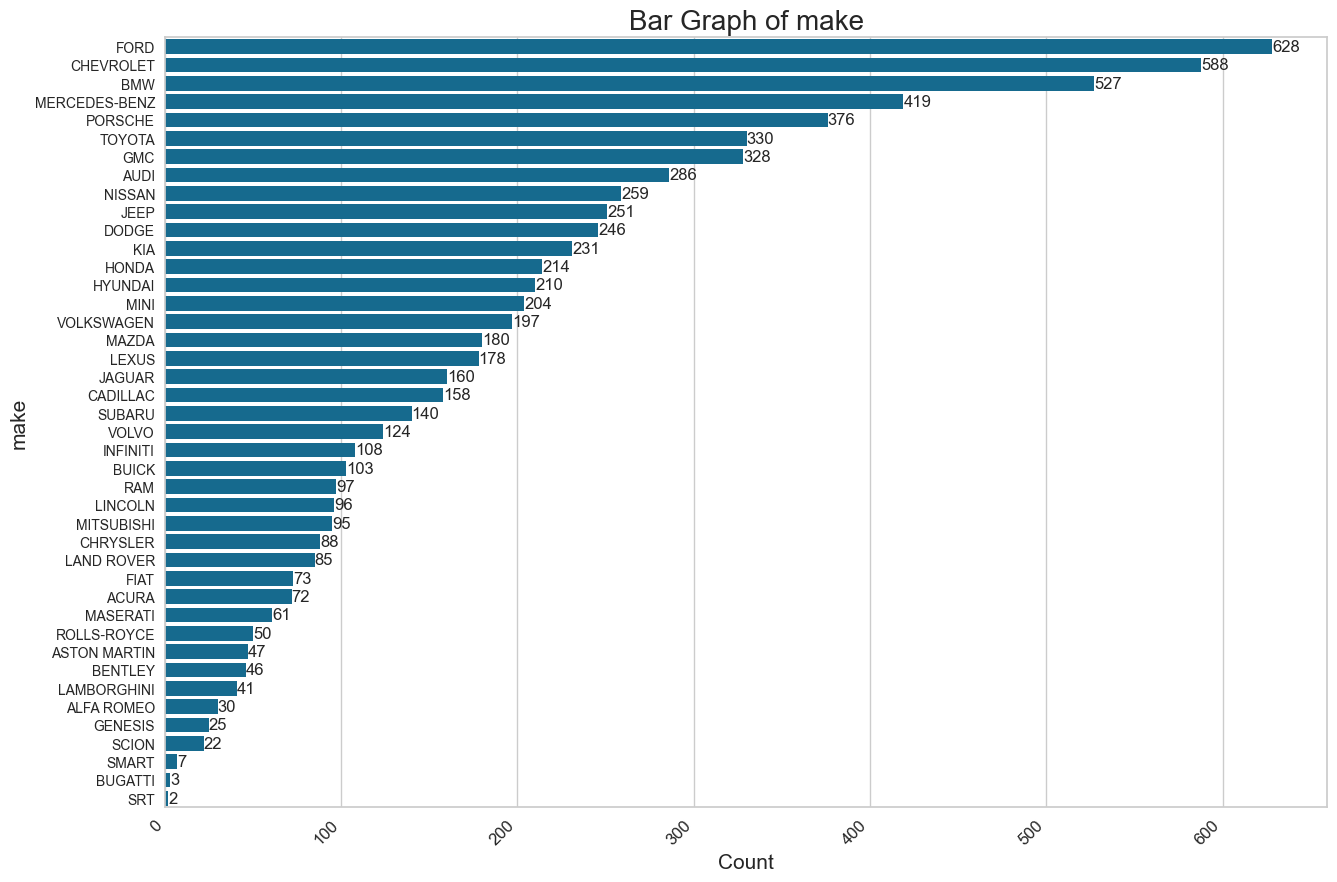

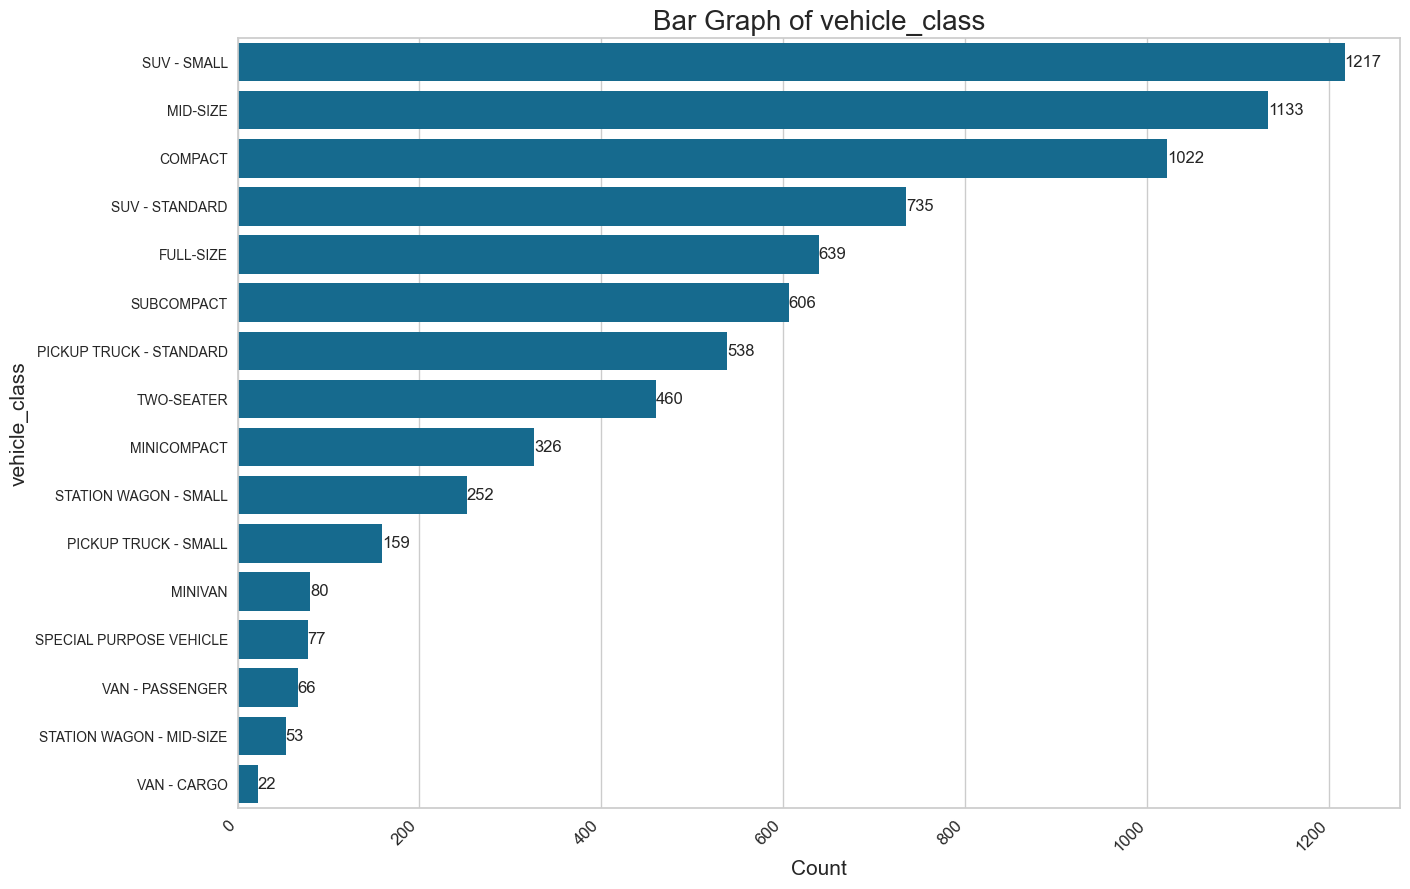

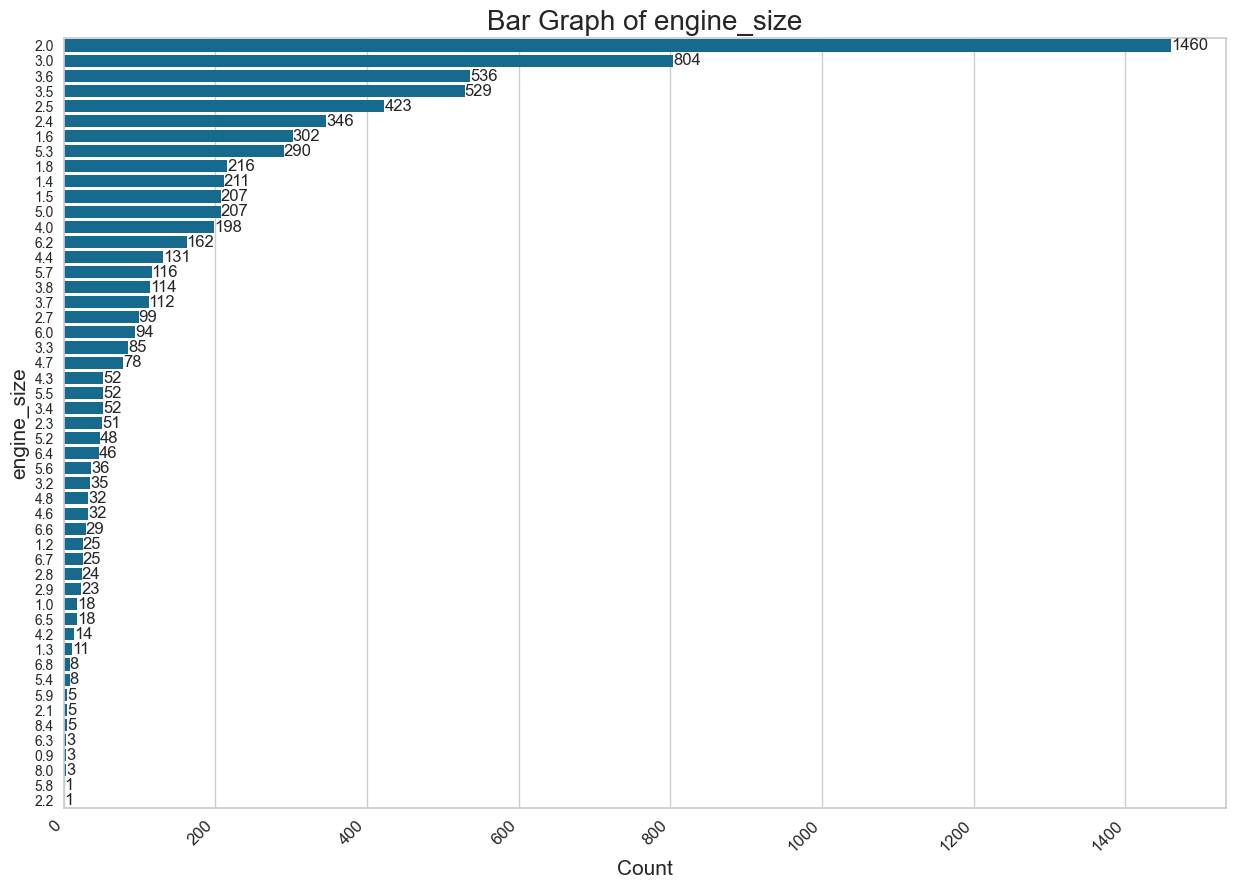

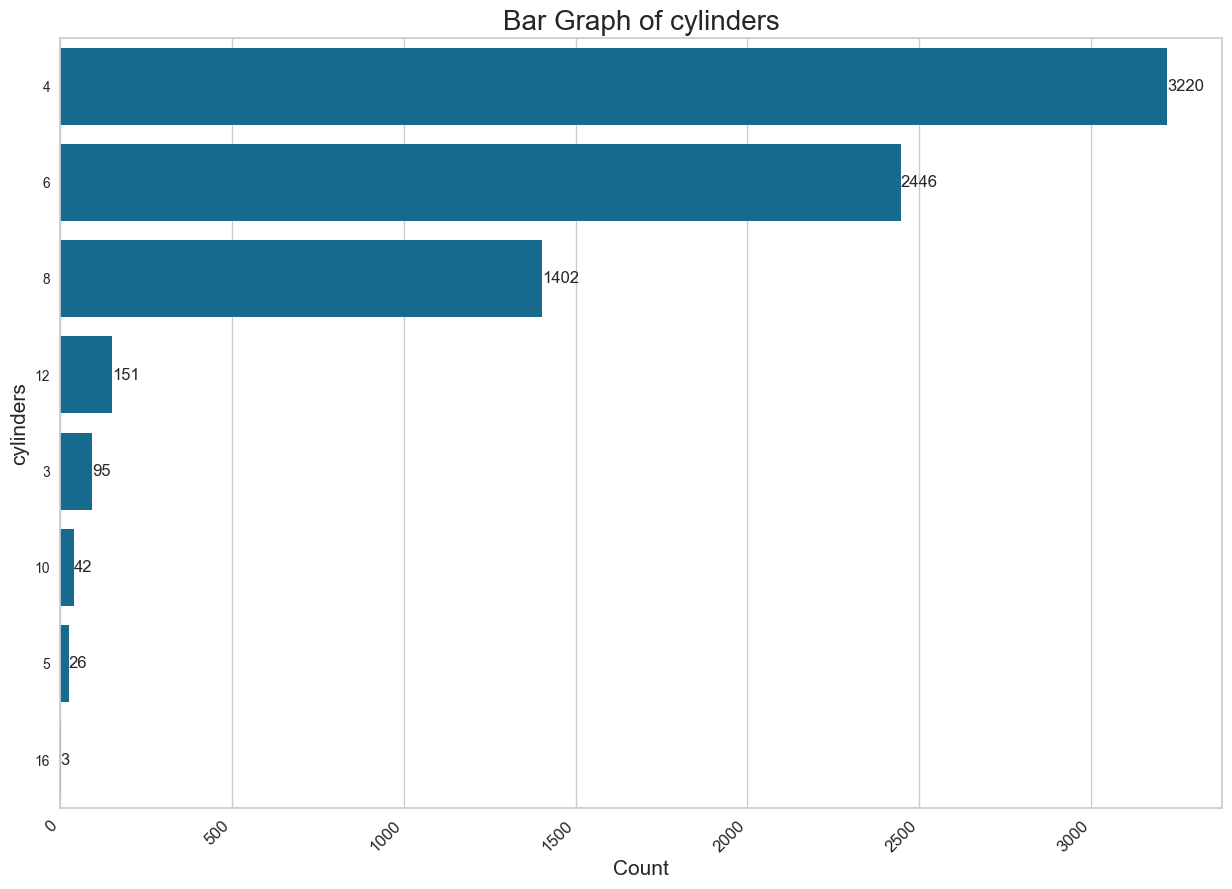

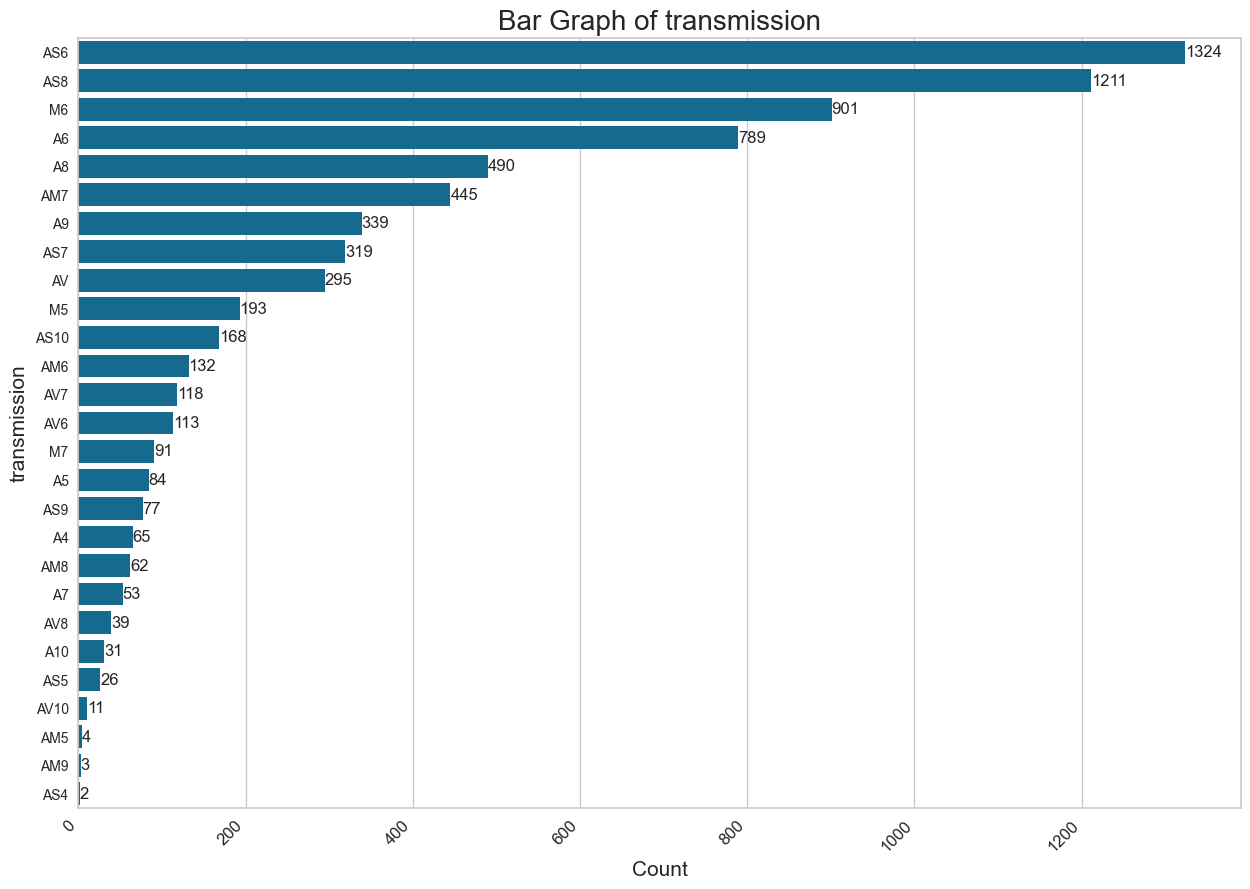

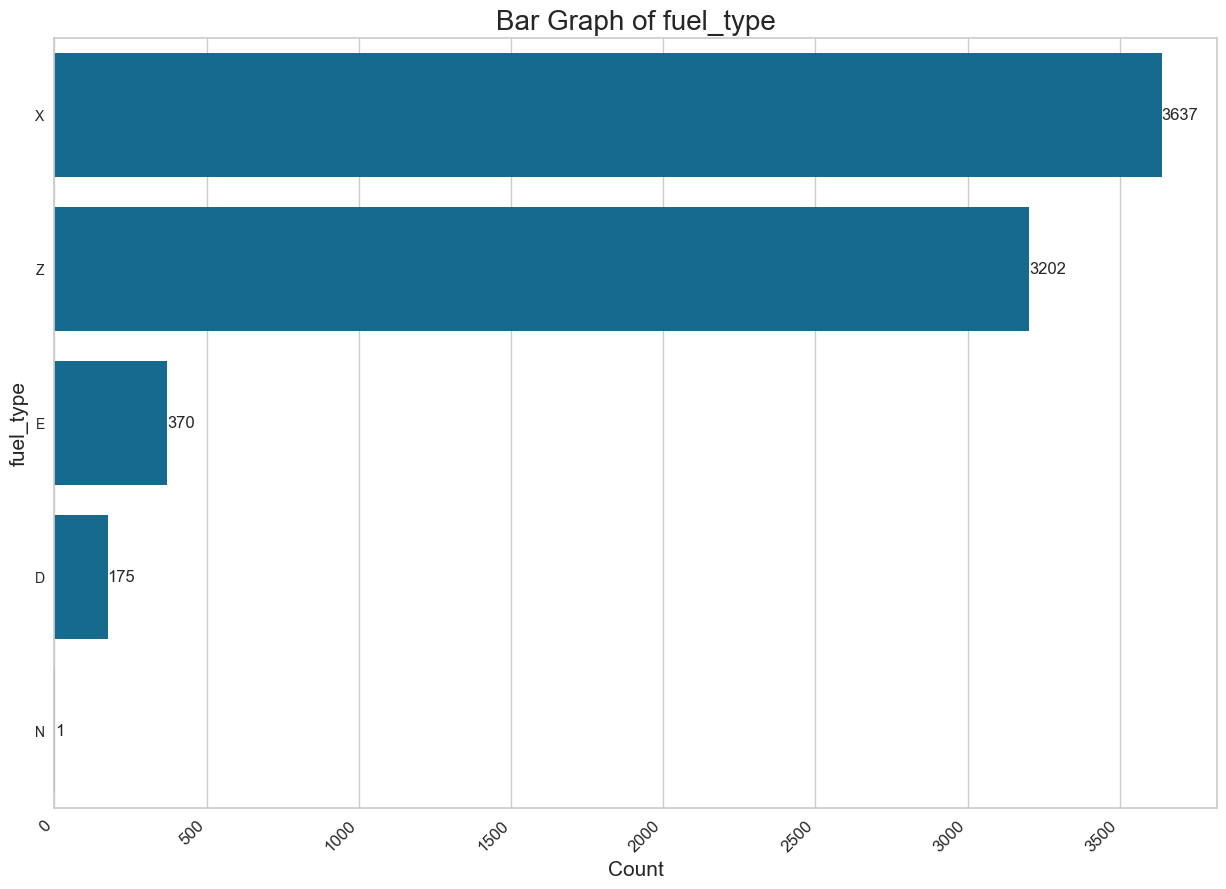

In [245]:
# Let's look at the distribution of our categorical characteristics with a bar graph

def plot_bar_graphs(df, columns):
    for column in columns:
        plt.figure(figsize=(15, 10))
        ax = sns.countplot(y=column, data=df, order=df[column].value_counts().index)
        ax.bar_label(ax.containers[0],rotation=0)
        plt.ylabel(column, fontsize=15)
        plt.xlabel('Count', fontsize=15)
        plt.title(f'Bar Graph of {column}', fontsize=20)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.show()
        
cat_features = ['make','vehicle_class', 'engine_size', 'cylinders', 'transmission', 'fuel_type']

plot_bar_graphs(df, cat_features)

In [246]:
# Model Feature

df.model.unique()

<StringArray>
[                                   'ILX',
                             'ILX HYBRID',
                                'MDX 4WD',
                                'RDX AWD',
                                    'RLX',
                                     'TL',
                                 'TL AWD',
                                    'TSX',
                                     '4C',
                                    'DB9',
 ...
                      'Camry AWD XLE/XSE',
                            'Corolla XLE',
                            'Corolla XSE',
                         'Corolla Hybrid',
                               'GR Supra',
 'Highlander Hybrid AWD Limited/Platinum',
                  'RAV4 AWD TRD Off-Road',
      'Tacoma 4WD D-Cab TRD Off-Road/Pro',
              'Atlas Cross Sport 4MOTION',
                            'XC40 T4 AWD']
Length: 2053, dtype: str

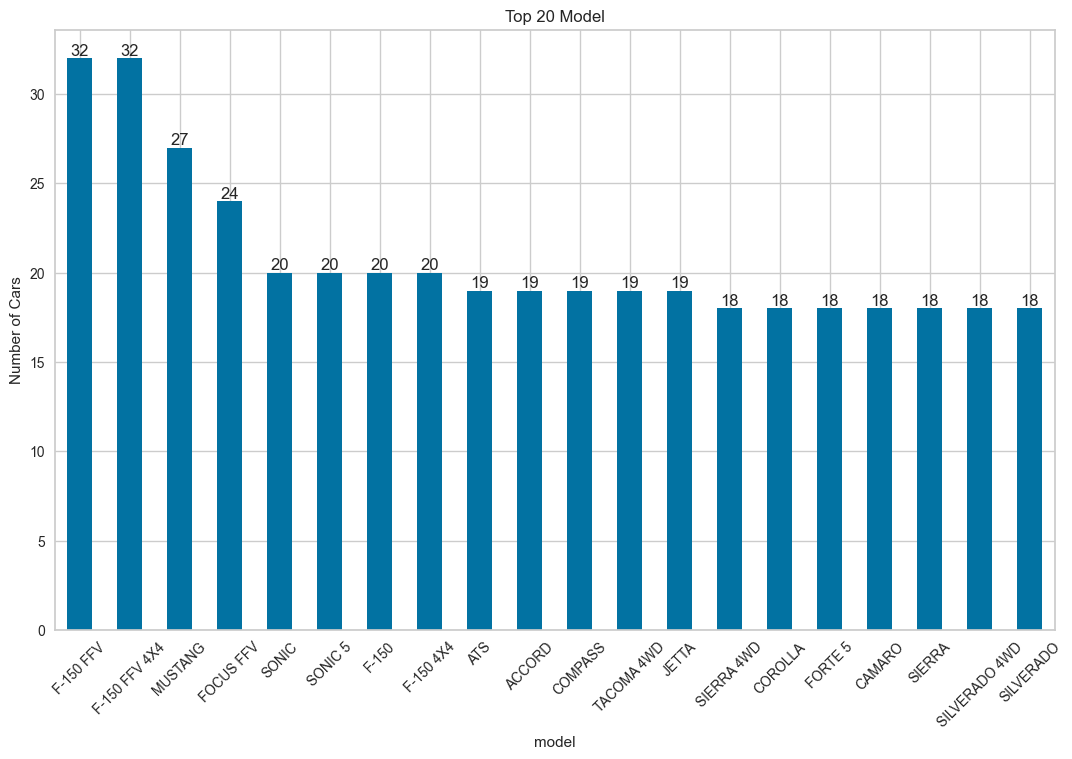

In [247]:
fig = plt.figure(figsize = (10,6))
ax = fig.add_axes([0,0,1,1])
counts = df.model.value_counts().sort_values(ascending=False).head(20)
counts.plot(kind = "bar")
plt.title('Top 20 Model')   
plt.xlabel('model') 
plt.ylabel('Number of Cars')
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0], labels=counts.values, fontsize=12);

As can be seen from the graphs above:

The number of vehicles consuming diesel, ethanol and natural gas fuel in the data set is very small.
Widespread use of AS6, AS8, M6, A6, A9 as transmission options

4, 6, 8 are commonly used as cylinders option

Engine Size (L) with 2.0 and 3.0 options in density

The dataset is generally dominated by smaller sized vehicles

### Target Variable vs Categorical Features

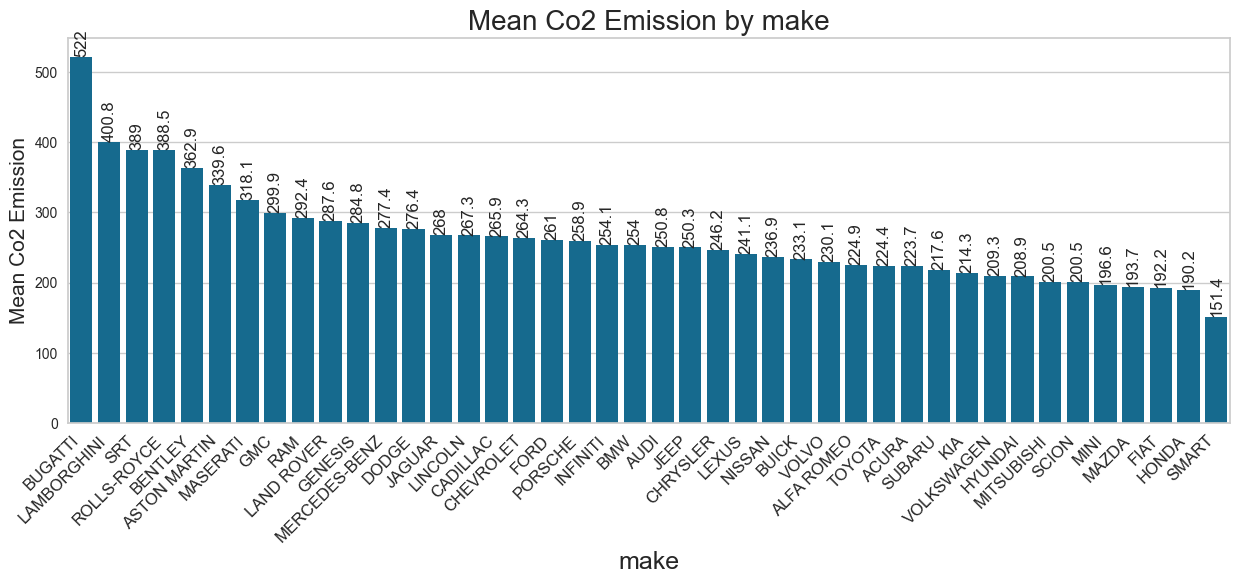

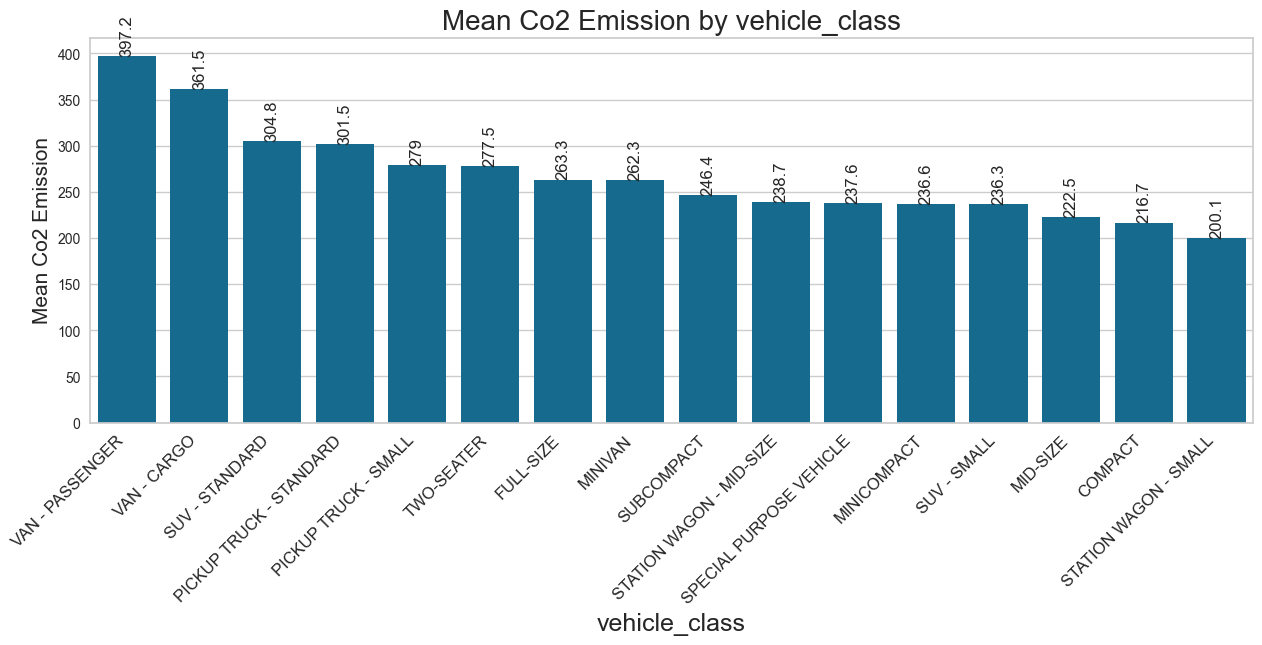

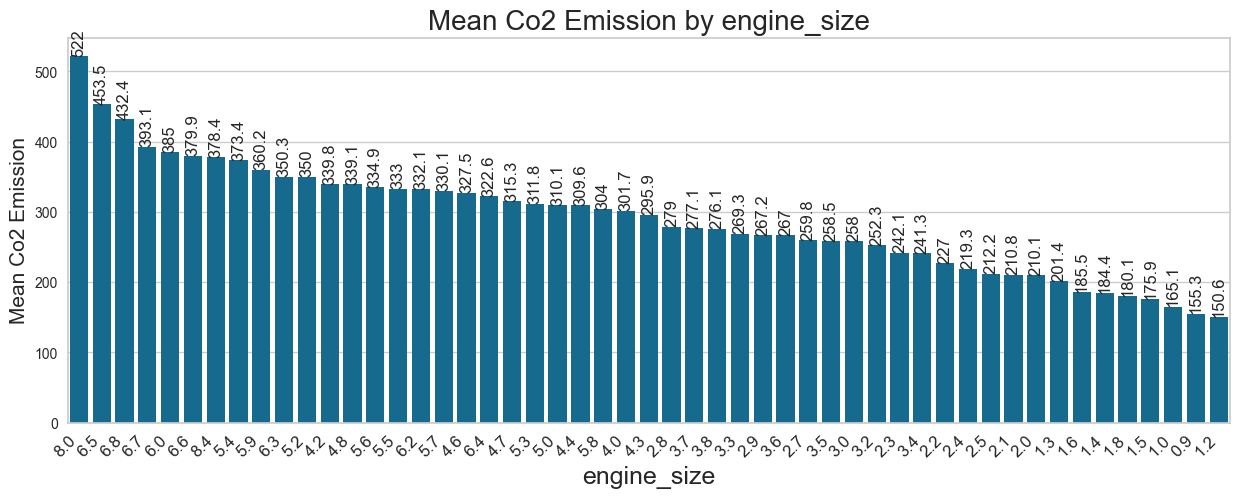

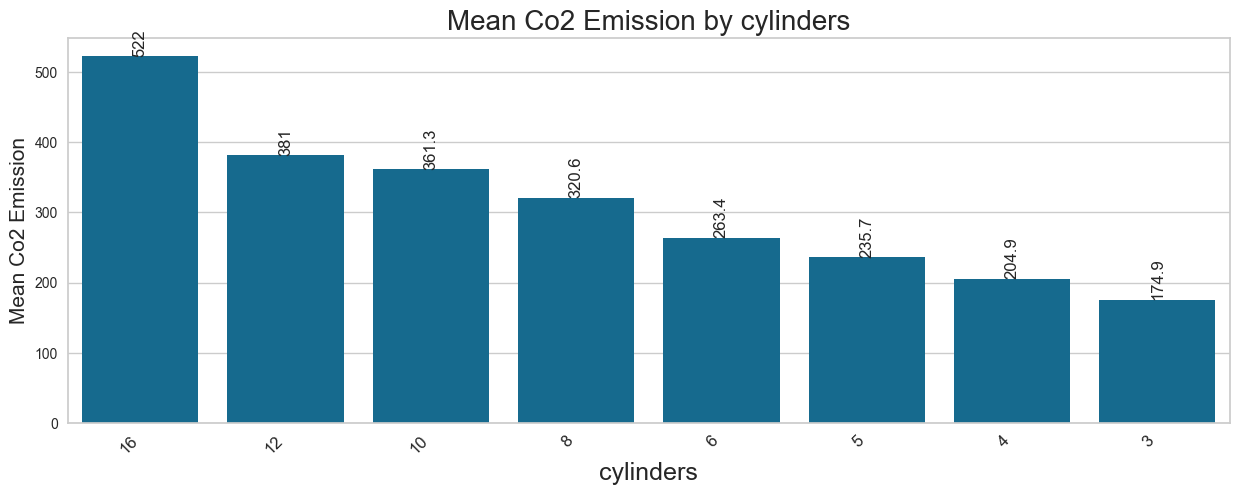

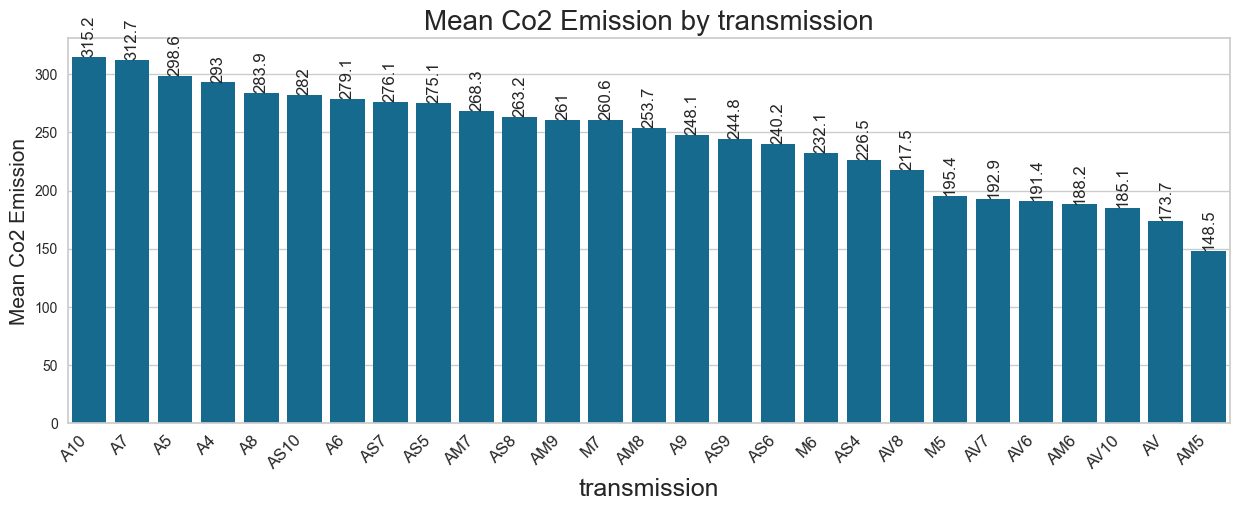

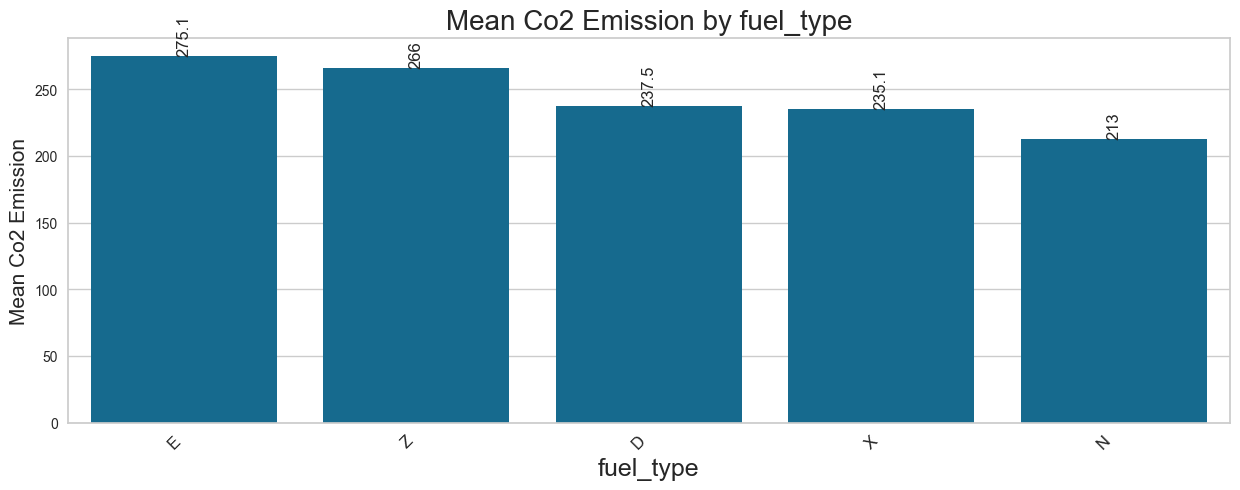

In [248]:
# Let's look at the relationship between our categorical attributes and the target variable

def plot_bar_with_co2(df, columns):
    for column in columns:
        plt.figure(figsize=(15, 5))
        grouped_data = df.groupby(column)['co2'].mean().round(1).reset_index()
        grouped_data_sorted = grouped_data.sort_values(by='co2', ascending=False)
        ax = sns.barplot(x=column, y='co2', data=grouped_data_sorted, order=grouped_data_sorted[column])
        ax.bar_label(ax.containers[0],rotation=90)
        plt.xlabel(column, fontsize=18)
        plt.ylabel('Mean Co2 Emission', fontsize=15)
        plt.title(f'Mean Co2 Emission by {column}', fontsize=20)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.show()
        
plot_bar_with_co2(df, cat_features)

As can be seen from the graphs above:

Bugatti has the highest average Co2 emissions <br>
Large-volume vehicles have high CO2 emission averages<br>
C02 emission averages of high volume and cylinders engines are also high<br>
Ethanol is the fuel with the highest average CO2

In [249]:
# Perform ANOVA test for each categorical feature
anova_results = {}
categorical_features = df.select_dtypes(include=['object']).columns

for feature in categorical_features:
    groups = [df["co2"][df[feature] == category].values for category in df[feature].unique()]
    anova_results[feature] = stats.f_oneway(*groups)

# Display the ANOVA results
for feature, result in anova_results.items():
    print(f"ANOVA result for {feature}:")
    print(f"F-statistic: {result.statistic}, p-value: {result.pvalue}")
    print()


ANOVA result for make:
F-statistic: 106.8000265413262, p-value: 0.0

ANOVA result for model:
F-statistic: 58.405091462865016, p-value: 0.0

ANOVA result for vehicle_class:
F-statistic: 266.0228094521597, p-value: 0.0

ANOVA result for transmission:
F-statistic: 103.70394951088049, p-value: 0.0

ANOVA result for fuel_type:
F-statistic: 148.94555963595639, p-value: 1.0628103972934153e-122



NOTE:

The p-values for each of the Make, Model, Vehicle Class, Transmission, and Fuel Type variables are much smaller than 0.05, indicating that these variables create statistically significant differences in co2_emissions.

### Lable Encoding the Categorical Features

In [250]:
from sklearn.preprocessing import LabelEncoder

# Copy the original dataframe to avoid modifying it directly
df_labeled = df.copy()

# List of categorical columns
categorical_columns = ['make', 'model', 'vehicle_class', 'transmission', 'fuel_type']

# Apply Label Encoding to each categorical column
label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    df_labeled[column] = le.fit_transform(df_labeled[column])
    label_encoders[column] = le

# Display the first few rows of the labeled dataframe
print(df_labeled.head())

   make  model  vehicle_class  engine_size  cylinders  transmission  \
0     0   1057              0          2.0          4            14   
1     0   1057              0          2.4          4            25   
2     0   1058              0          1.5          4            22   
3     0   1233             11          3.5          6            15   
4     0   1499             11          3.5          6            15   

   fuel_type  fuel_cons_city  fuel_cons_hwy  fuel_cons_comb  \
0          4             9.9            6.7             8.5   
1          4            11.2            7.7             9.6   
2          4             6.0            5.8             5.9   
3          4            12.7            9.1            11.1   
4          4            12.1            8.7            10.6   

   fuel_cons_comb_mpg  co2  
0                  33  196  
1                  29  221  
2                  48  136  
3                  25  255  
4                  27  244  


In [251]:
df_labeled.info()

<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make                7385 non-null   int64  
 1   model               7385 non-null   int64  
 2   vehicle_class       7385 non-null   int64  
 3   engine_size         7385 non-null   float64
 4   cylinders           7385 non-null   int64  
 5   transmission        7385 non-null   int64  
 6   fuel_type           7385 non-null   int64  
 7   fuel_cons_city      7385 non-null   float64
 8   fuel_cons_hwy       7385 non-null   float64
 9   fuel_cons_comb      7385 non-null   float64
 10  fuel_cons_comb_mpg  7385 non-null   int64  
 11  co2                 7385 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 692.5 KB


### Correlation Matrix

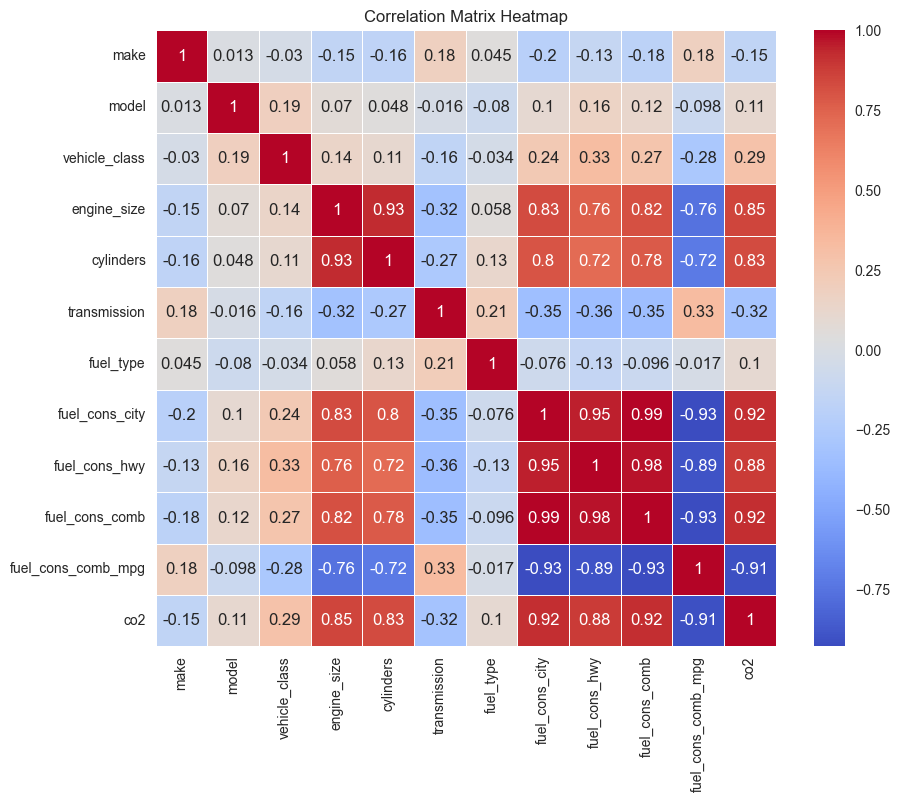

In [252]:
correlation_matrix = df_labeled.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

The correlation matrix shows that features like engine_size, cylinders, and fuel consumption metrics (city, highway, combined) have strong positive correlations with co2_emissions.
Notably, fuel_cons_mpg has a strong negative correlation with CO2 emissions, indicating that higher fuel efficiency results in lower emissions.

From a multicollinearity perspective, fuel_cons_city, fuel_cons_hwy, and fuel_cons_comb are highly intercorrelated, suggesting potential redundancy.

It may be beneficial to select just one or combine them into a single metric to avoid multicollinearity.
Key predictors for a CO2 emissions model include engine_size, cylinders, and fuel consumption metrics.

Categorical features such as make, model, vehicle_class, transmission, and fuel_type are also important due to their significant impact on CO2 emissions.
Managing multicollinearity among these highly correlated features is crucial to ensure model stability and performance.

## 1.2.2. Numerical Features

#### Distribution of Numerical Features

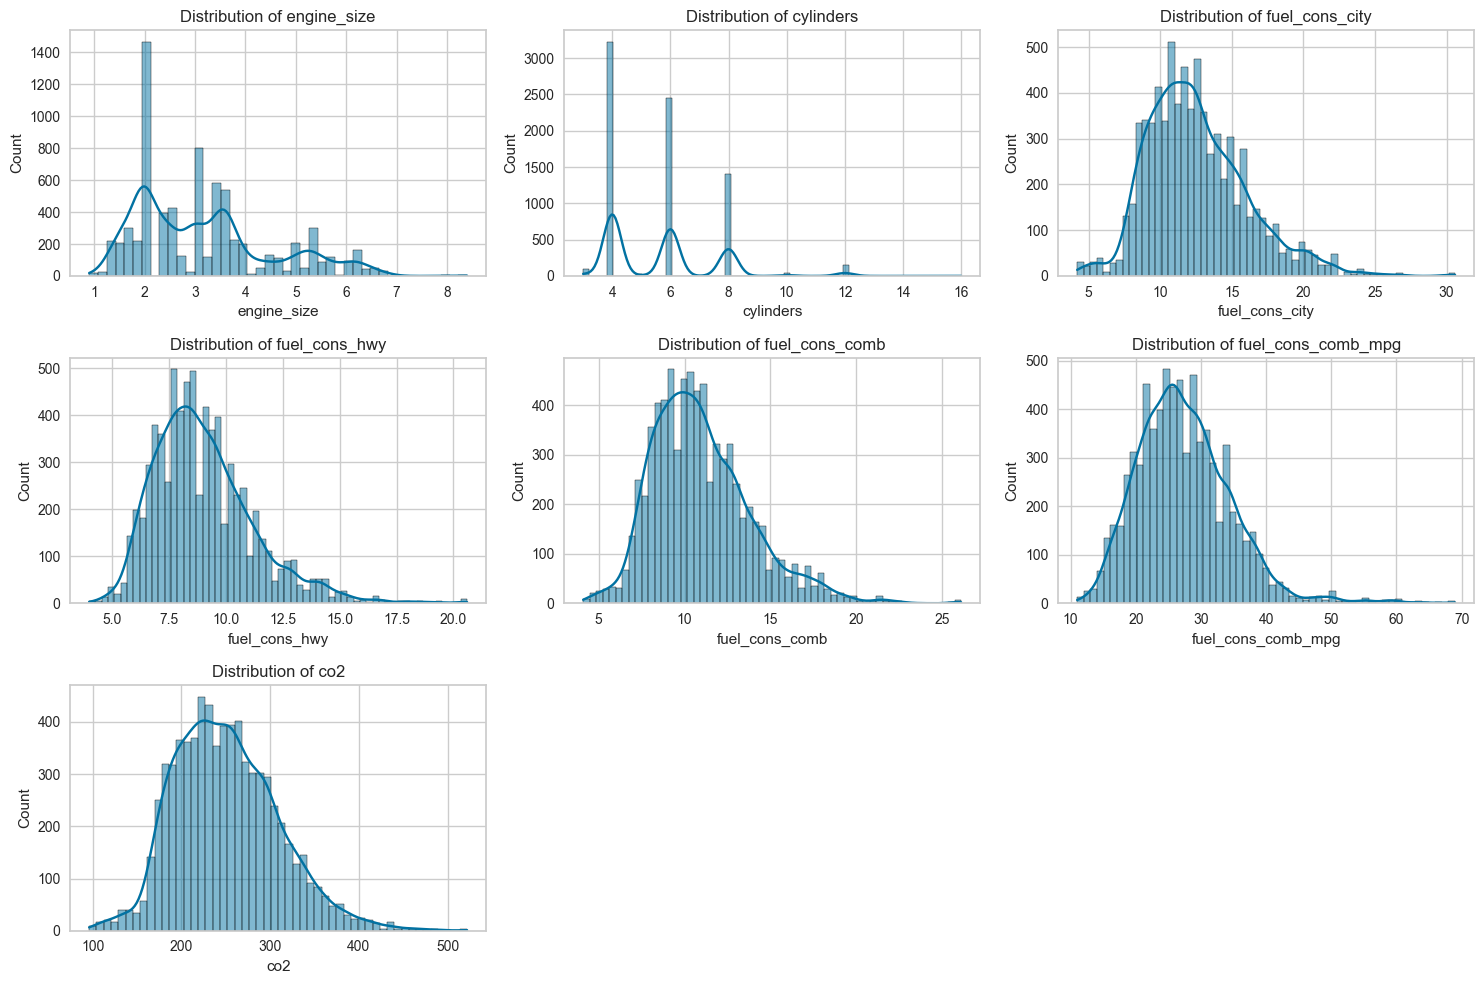

In [253]:
numerical_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(15, 10))

num_vars = len(numerical_df.columns)

for i, var in enumerate(numerical_df.columns, 1):
    plt.subplot((num_vars // 3) + 1, 3, i)
    sns.histplot(data=df, x=var, kde=True)
    plt.title(f'Distribution of {var}')
    
plt.tight_layout()
plt.show()

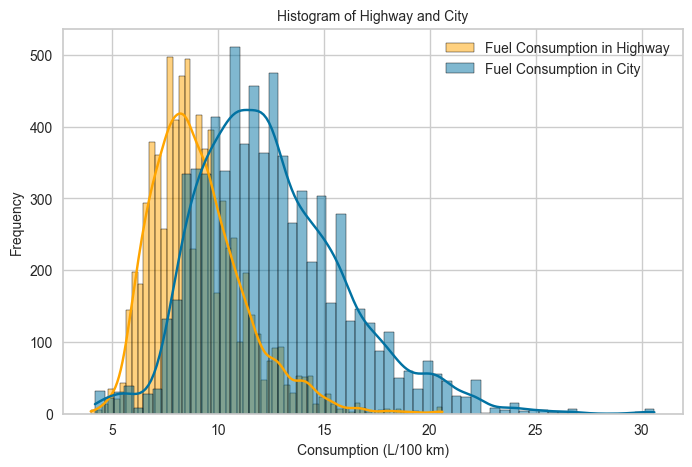

In [254]:
# Consumption of Highway and City

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="fuel_cons_hwy", kde=True, label = "Fuel Consumption in Highway",color = "orange")
sns.histplot(data=df, x="fuel_cons_city", kde=True, label = "Fuel Consumption in City")
plt.xlabel('Consumption (L/100 km)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title(f'Histogram of Highway and City', fontsize=10)
plt.legend()
plt.show()

Engine Size (engine_size): The distribution is skewed with several peaks, indicating different types of vehicles with varying engine sizes.<br>
Cylinders: The distribution is concentrated around specific values (4, 6, 8), reflecting common engine types in the dataset.<br>
Fuel Consumption City (fuel_cons_city): The distribution is approximately normal, which is beneficial for model learning.<br>
Fuel Consumption Hwy (fuel_cons_hwy): Similar to city fuel consumption, this also shows an approximately normal distribution.<br>
Fuel Consumption Combined (fuel_cons_comb): The combined fuel consumption distribution is normal, making it a useful variable for modeling.<br>
Fuel Consumption MPG (fuel_cons_mpg): This shows a normal distribution and has an inverse relationship with other fuel consumption metrics, which is expected.<br>
CO2 Emissions (co2): The distribution is nearly normal, which is advantageous for regression models.

#### Overall Evaluation:

Most features exhibit normal or skew-normal distributions, which are suitable for modeling.<br>
Consider multicollinearity, especially among fuel_cons_City, fuel_cons_Hwy, and fuel_cons_Comb.<br>
Features like cylinders, engine_size, and fuel_cons_mpg provide important information about vehicle performance and efficiency, making them valuable for the model.<br>

#### Target vs Numeric Features

Text(86.47222222222221, 0.5, 'CO2 Emissions (g/km)')

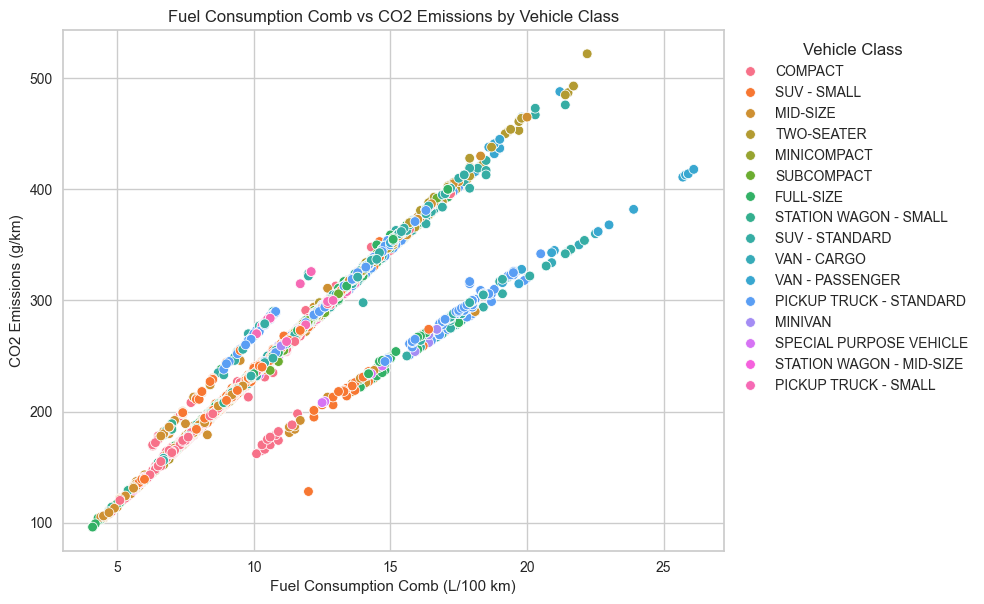

In [255]:
# Target vs Fuel Consumption Combined (city+hwy)
# Hue: Vehicle Class

plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='fuel_cons_comb',y='co2',hue='vehicle_class')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Vehicle Class')
plt.tight_layout()

plt.title('Fuel Consumption Comb vs CO2 Emissions by Vehicle Class')
plt.xlabel('Fuel Consumption Comb (L/100 km)')
plt.ylabel('CO2 Emissions (g/km)')

# Vehicle class makes impact on overall fuel efficiency of vehicle as well lead to more emission
# Two-Seater,Mid Size, Passenger van, Cargo van, Pick Up Truck have most emission with lowest fuel efficiency
# Mini Van, SPV, Station Wagon are more fuel efficienct with low emission

Text(0, 0.5, 'CO2 Emissions (g/km)')

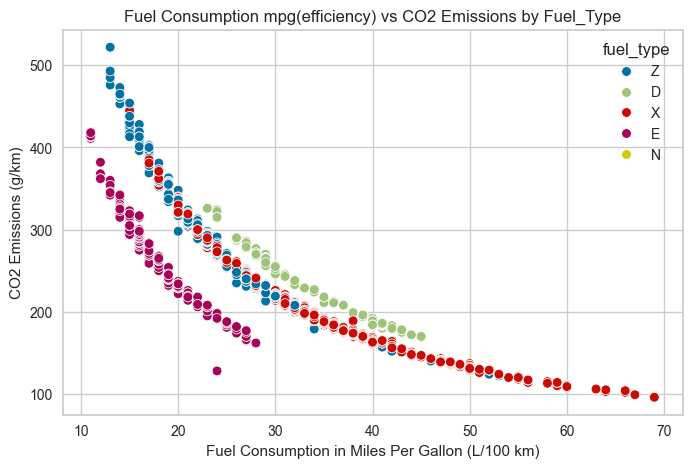

In [256]:
# Target vs Fuel Consumption in Miles Per Gallon (mpg)
# Hue: Fuel Type 

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='fuel_cons_comb_mpg',y='co2',hue='fuel_type')

plt.title('Fuel Consumption mpg(efficiency) vs CO2 Emissions by Fuel_Type')
plt.xlabel('Fuel Consumption in Miles Per Gallon (L/100 km)')
plt.ylabel('CO2 Emissions (g/km)')

Text(86.47222222222221, 0.5, 'CO2 Emissions (g/km)')

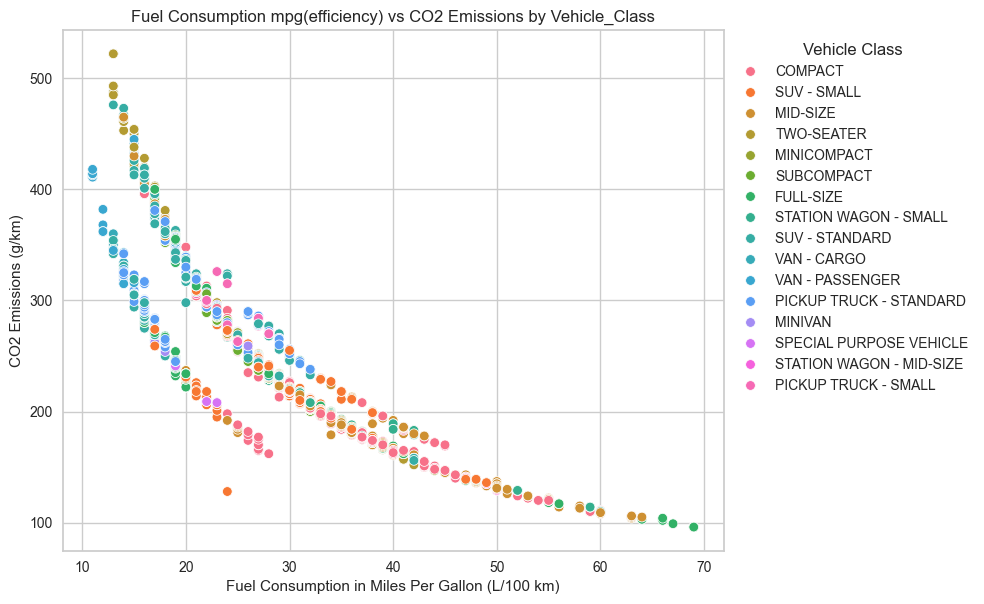

In [257]:
# Target vs Fuel Consumption in Miles Per Gallon
# Hue: Vehicle Class

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='fuel_cons_comb_mpg',y='co2',hue='vehicle_class')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Vehicle Class')
plt.tight_layout()

plt.title('Fuel Consumption mpg(efficiency) vs CO2 Emissions by Vehicle_Class')
plt.xlabel('Fuel Consumption in Miles Per Gallon (L/100 km)')
plt.ylabel('CO2 Emissions (g/km)')

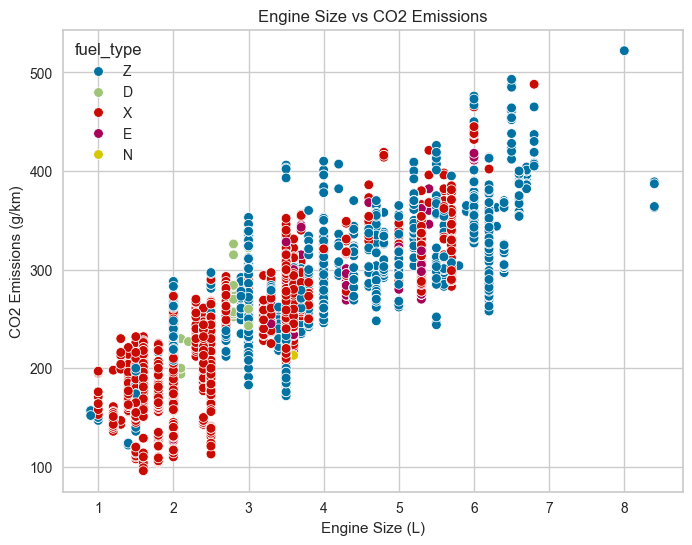

In [258]:
# Target vs Engine Size

plt.figure(figsize=(8, 6))
sns.scatterplot(x='engine_size', y='co2', data=df, hue='fuel_type')
plt.title('Engine Size vs CO2 Emissions')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

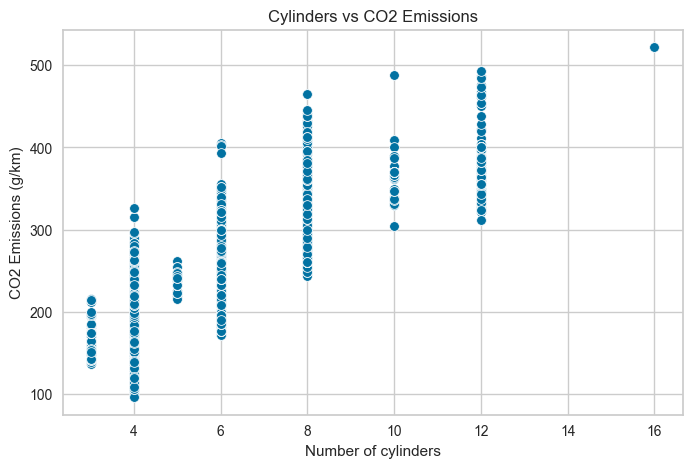

In [259]:
# Target vs Cylinders Number

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='cylinders',y='co2')

plt.title('Cylinders vs CO2 Emissions')
plt.xlabel('Number of cylinders')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()
# Vehicles with more cylinders tend to have higher emission

#### Correlation of numerical features

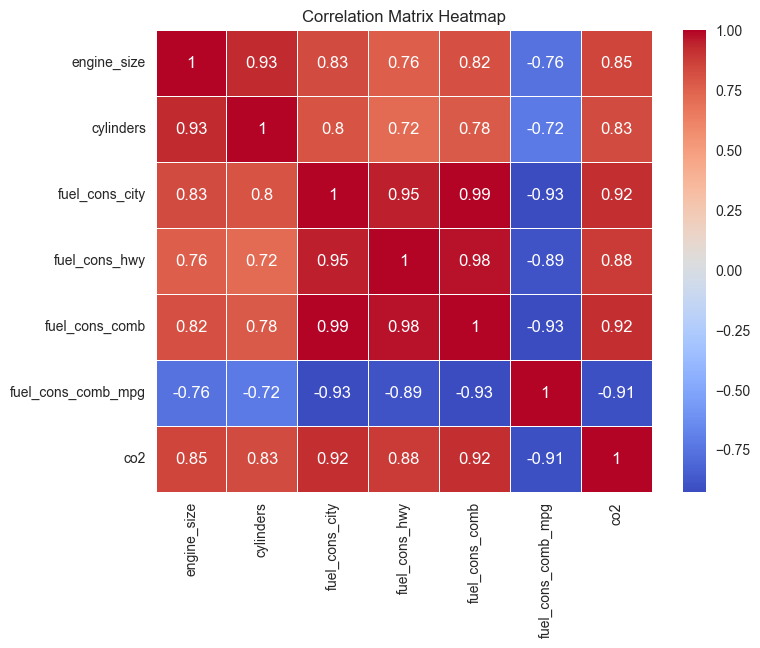

In [260]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

The correlation matrix shows strong multicollinearity among several features. Specifically:

fuel_cons_city, fuel_cons_hwy, and fuel_cons_comb have very high correlations (0.95 and above), indicating they carry almost identical information.<br>
engine_size and cylinders are also highly correlated (0.93).<br>
co2_emissions has strong positive correlations with fuel_cons_comb, fuel_cons_city, and engine_size (0.85 and above), indicating these features are important for predicting CO2 emissions.<br>
fuel_cons_mpg shows high negative correlations with other fuel consumption measures (-0.93 and above), as higher mpg indicates lower fuel consumption.<br>
These findings suggest that removing some highly correlated features can help reduce multicollinearity and improve model performance.<br>

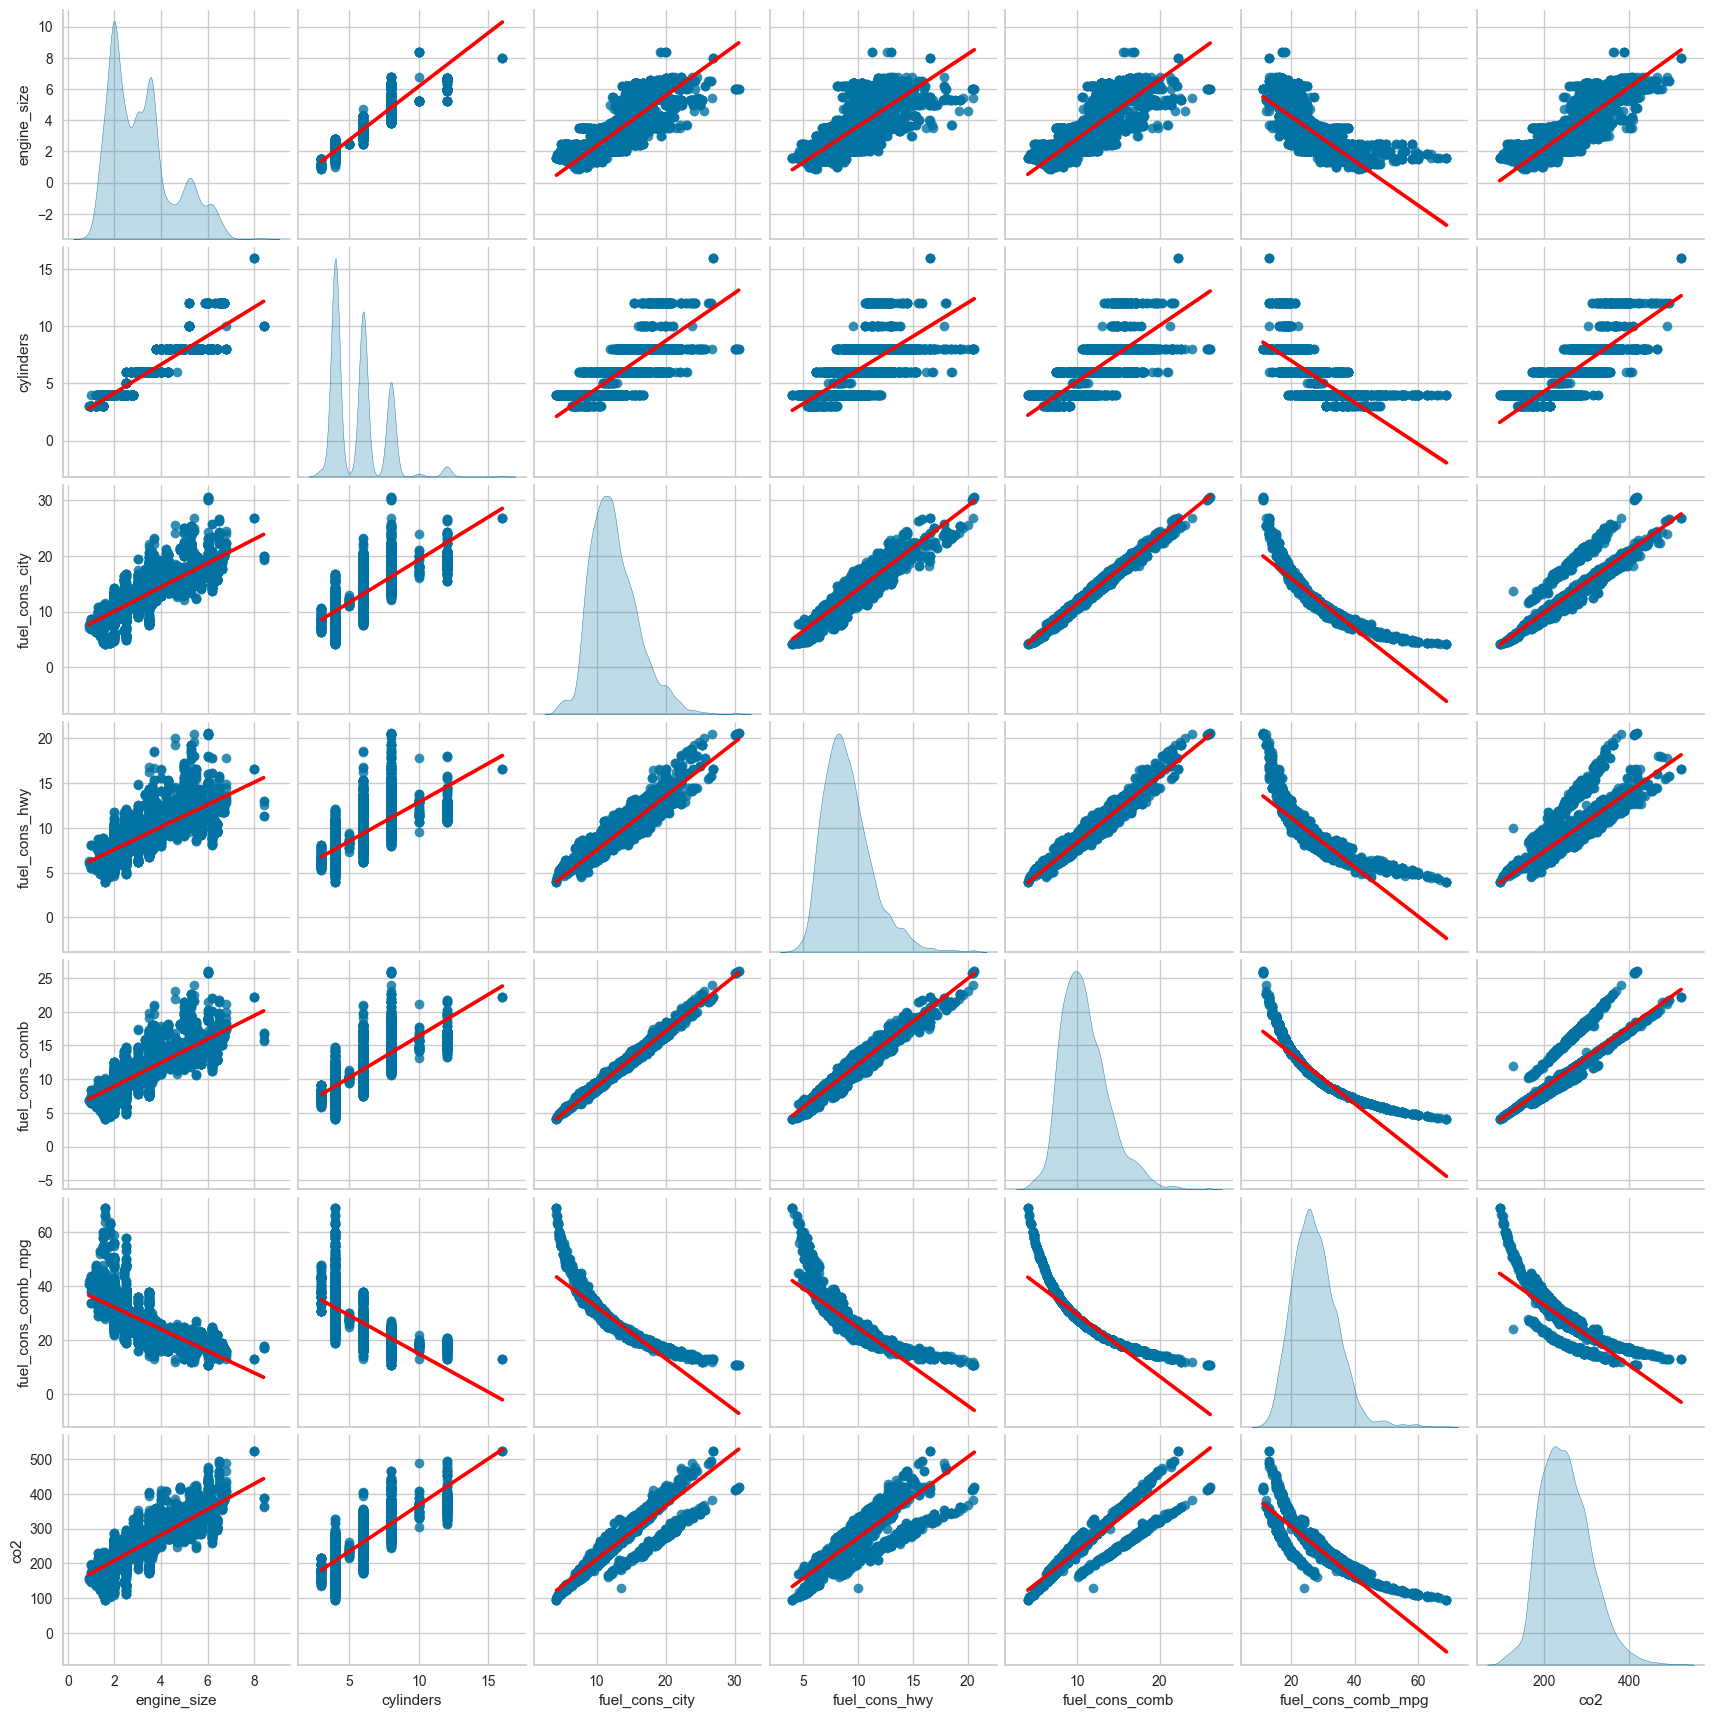

In [261]:
# Pairplot for the dataframe

sns.pairplot(df,
             kind="reg",
             diag_kind="kde", 
             plot_kws={"line_kws": {"color": "red"}}
            )

The pairplot shows the relationships and distributions between various numerical features in the dataset. Here's a brief analysis:

Engine Size (engine_size):

Positively correlated with cylinders, fuel_cons_city, fuel_cons_hwy, fuel_cons_comb, and co2.
Larger engines tend to have more cylinders and higher fuel consumption.
Cylinders:

Strong positive correlation with engine_size and fuel consumption metrics.
As the number of cylinders increases, fuel consumption and CO2 emissions also increase.
Fuel Consumption City (fuel_cons_City):

High positive correlation with fuel_cons_hwy, fuel_cons_comb, and co2.
Vehicles that consume more fuel in the city tend to consume more on highways and produce higher CO2 emissions.
Fuel Consumption Hwy (fuel_cons_Hwy):

Similar correlations as city fuel consumption, showing strong positive relationships with fuel_cons_city, fuel_cons_comb, and co2.


Fuel Consumption Combined (fuel_cons_Comb):

Very high correlation with both city and highway fuel consumption.
Indicative of overall vehicle efficiency.
Fuel Consumption MPG (fuel_cons_mpg):

Shows a strong negative correlation with other fuel consumption metrics and co2.
Higher MPG values indicate better fuel efficiency and lower CO2 emissions.
fuel efficiency increases (mpg value increases), CO2 emissions decrease.
CO2 Emissions (co2):

Strongly correlated with engine_size, cylinders, fuel_cons_city, fuel_cons_hwy, and fuel_cons_comb.
Vehicles with larger engines, more cylinders, and higher fuel consumption emit more CO2.
Overall Evaluation:

The pairplot reveals strong relationships among features, particularly between engine size, fuel consumption, and CO2 emissions.
The negative correlation between MPG and other features highlights its importance in representing fuel efficiency.
Suggest focusing on features like fuel_cons_comb, engine_size, and fuel_cons_mpg for predictive modeling, while considering multicollinearity.

#### Outlier Analysis

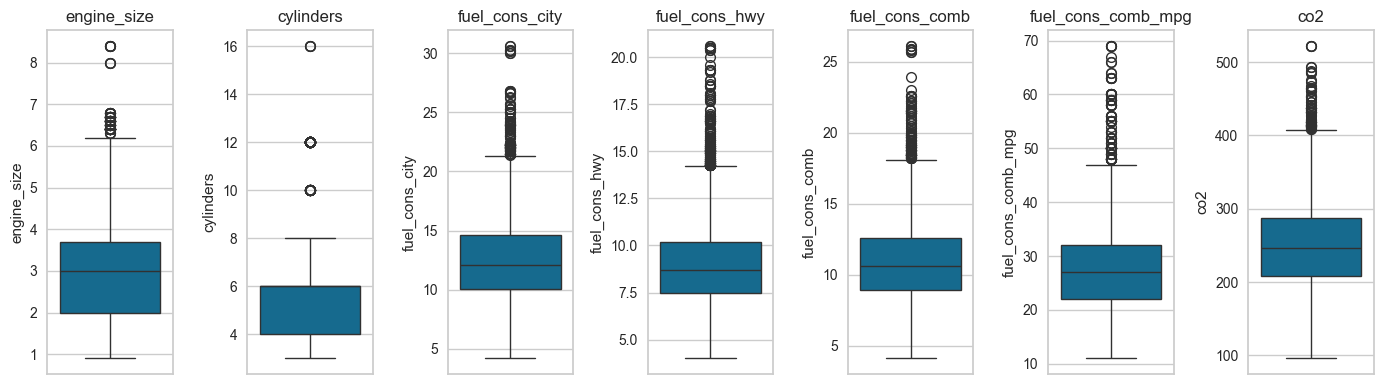

In [262]:
# Checking Outliers

# Initialize the subplot counter
x = 0

# Create a figure with specified size
plt.figure(figsize=(16, 4))

# Loop through each numerical column and create a boxplot
for col in df.select_dtypes(include=['number']).columns:
    x += 1
    plt.subplot(1, 8, x)
    sns.boxplot(data=df[col])
    plt.title(col)

# Show the plots
plt.tight_layout()  # Adjust subplots to fit in the figure area.
plt.show()

We do not intervene with outliers at the moment, but we can take action later according to the model's forecasting performance.

### 1.4. Skewness

In [263]:
# Calculate skewness for numeric features

# A skewness value greater than 1 indicates positive skewness,
# a skewness value less than -1 indicates negative skewness,
# and a skewness value close to zero indicates a relatively symmetric distribution.

num_cols= df.select_dtypes('number').columns

skew_limit = 0.75               # define a limit above which we will log transform
skew_vals = df[num_cols].skew()


# Showing the skewed columns
skew_cols = (skew_vals
             .sort_values(ascending=False)
             .to_frame()
             .rename(columns={0:'Skew'})
             .query('abs(Skew) > {}'.format(skew_limit)))
skew_cols

,Skew
cylinders,1.110415
fuel_cons_hwy,1.079217
fuel_cons_comb_mpg,0.977034
fuel_cons_comb,0.893316
engine_size,0.809181
fuel_cons_city,0.809005


# 2. MACHINE LEARNING

The objective of creating and using a model with the CO2 emission dataset is to build machine learning algorithms capable of accurately predicting vehicle CO2 emissions based on their characteristics.<br>

By examining variables such as engine size, number of cylinders, and fuel consumption, the aim is to develop models that can evaluate the environmental impact of different vehicles and guide policy decisions aimed at reducing carbon emissions.<br>

Additionally, these models can support automotive manufacturers in designing more fuel-efficient vehicles and help consumers make informed choices when selecting vehicles with lower carbon footprints.
Ultimately, the goal is to harness data-driven insights to mitigate the environmental impact of transportation and promote sustainable development.<br>

Evaluating model accuracy on both training and test sets is essential to determine whether the model is overfitting or underfitting the data, addressing the bias-variance tradeoff effectively.<br>

## 2.1. Simple Linear Regression Model¶

This simple linear regression model was built using only engine_size as the predictor and the target variable co2, without any data manipulation. This is often referred to as a "vanilla model."

<Axes: xlabel='engine_size', ylabel='co2'>

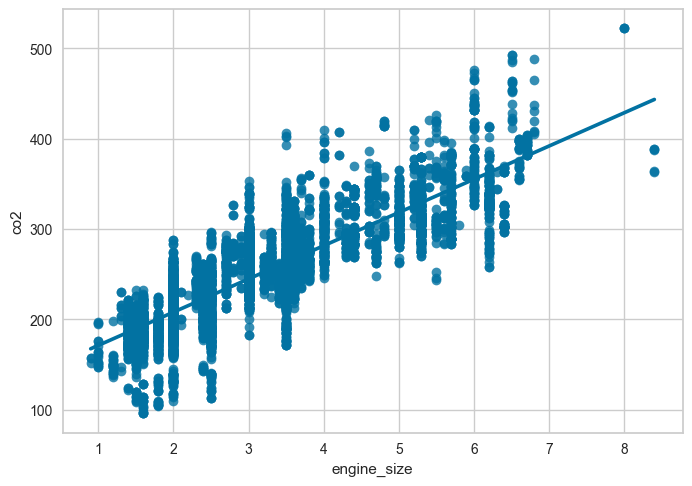

In [264]:
# Check the correlation between independent feature (engine_size) and target variable (co2_emissions)

sns.regplot(x = 'engine_size', y = 'co2', data=df, ci=None)

### Splitting data

In [265]:
# Split the selected independent feature (engine_size) and target variable (co2_emissions) for SIMPLE Linear Regression

X = df[['engine_size']] 
y = df['co2'] 

### Train | Test Split

In [266]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [267]:
# Display the shapes of the resulting datasets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5908, 1)
X_test shape: (1477, 1)
y_train shape: (5908,)
y_test shape: (1477,)


### Model

In [268]:
from sklearn.linear_model import LinearRegression

model_simple_lin_reg = LinearRegression() 

### Training the model

In [269]:
model_simple_lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Predicting against test dataset

In [270]:
# Predict using the model on the test data

y_train_pred = model_simple_lin_reg.predict(X_train)
y_pred = model_simple_lin_reg.predict(X_test)

### Evaluating performance

In [271]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def train_val(y_train, y_train_pred, y_test, y_pred, i): 
    
    scores = {
    i+"_train": {"R2" : r2_score(y_train, y_train_pred),
    "mae" : mean_absolute_error(y_train, y_train_pred),
    "mse" : mean_squared_error(y_train, y_train_pred),                          
    "rmse" : np.sqrt(mean_squared_error(y_train, y_train_pred))},
    
    i+"_test": {"R2" : r2_score(y_test, y_pred),
    "mae" : mean_absolute_error(y_test, y_pred),
    "mse" : mean_squared_error(y_test, y_pred),
    "rmse" : np.sqrt(mean_squared_error(y_test, y_pred))}
    }
    
    return pd.DataFrame(scores)

In [272]:
slr_score = train_val(y_train, y_train_pred, y_test, y_pred, 'linear')
slr_score

,linear_train,linear_test
R2,0.724528,0.723812
mae,23.374987,22.927177
mse,941.716358,949.985253
rmse,30.687397,30.821831


The difference between MAE and RMSE indicates outlier effect

In [273]:
avg_co2= df['co2'].mean()
avg_co2

np.float64(250.58469871360867)

In [274]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(30.821830791462343)

In [275]:
rmse/avg_co2

np.float64(0.12299965221215832)

To determine how much the error deviates from the mean of the target label.

According to the RMSE metric, our model has an average error rate of 12%.

Prefer the RMSE metric because it penalizes poor predictions.

In [276]:
# Comparing Actual y_test, Predicted_y and Residuals

my_dict = {"Actual": y_test, "pred": y_pred, "residual": y_test - y_pred}
compare = pd.DataFrame(my_dict)
compare.head(20)

,Actual,pred,residual
7261,253,244.893111,8.106889
4489,344,296.150160,47.849840
1539,322,362.052081,-40.052081
3532,297,329.101120,-32.101120
6418,308,281.505289,26.494711
3703,406,263.199200,142.800800
5976,242,244.893111,-2.893111
4332,216,208.280933,7.719067
5015,246,222.925804,23.074196
2087,223,226.587022,-3.587022


## 2.2. Multiple Linear Regression Model

We will now create a multiple linear regression model using 'engine_size', 'fuel_cons_comb', 'fuel_cons_hwy', and 'fuel_cons_city' as the independent variables and the target variable.

This model aims to capture the relationship between multiple predictors and the target variable for better prediction accuracy and insights.

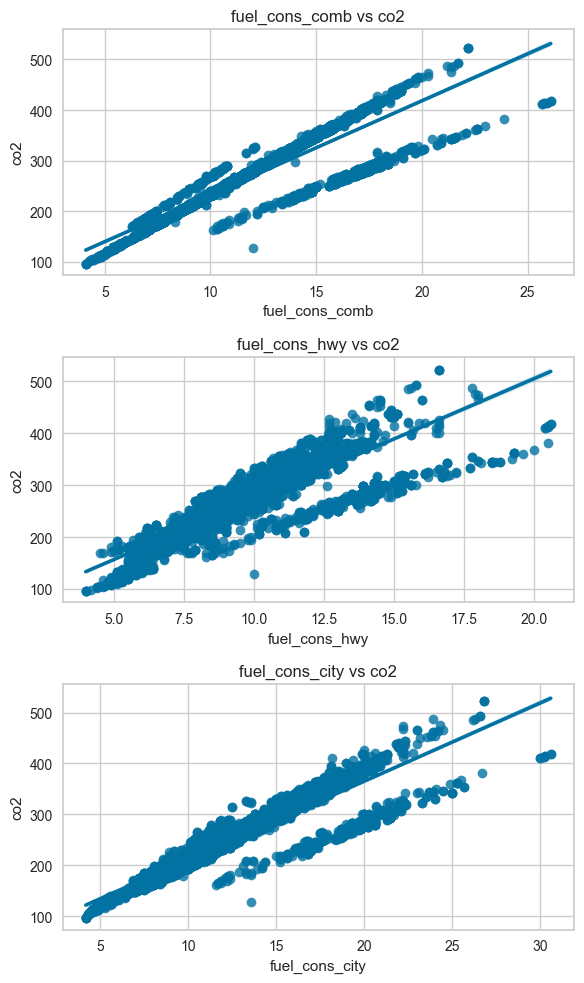

In [277]:
# See the relationship between independent features and target variable

independent_variables = ['fuel_cons_comb', 'fuel_cons_hwy','fuel_cons_city' ]
target_variable = 'co2'

plt.figure(figsize=(6,10))

for i, var in enumerate(independent_variables):
    plt.subplot(3,1, i + 1)
    sns.regplot(x=df[var], y=df[target_variable])
    plt.title(f'{var} vs {target_variable}')

plt.tight_layout()
plt.show()

### Splitting the data

In [278]:
X = df[["engine_size", "cylinders", "fuel_cons_comb", "fuel_cons_comb_mpg"]]
y = df["co2"]

In [279]:
X.head()

,engine_size,cylinders,fuel_cons_comb,fuel_cons_comb_mpg
0,2.0,4,8.5,33
1,2.4,4,9.6,29
2,1.5,4,5.9,48
3,3.5,6,11.1,25
4,3.5,6,10.6,27


In [280]:
# Check Multicolinarty between features

def color_custom(val):
    if val > 0.90 and val < 0.99:
        color = 'red'
    elif val >= 1:
        color = 'blue'
    else:
        color = 'black'
    return f'color: {color}'

In [281]:
pd.DataFrame(X).corr().style.map(color_custom)

,engine_size,cylinders,fuel_cons_comb,fuel_cons_comb_mpg
engine_size,1.000000,0.927653,0.817060,-0.757854
cylinders,0.927653,1.000000,0.780534,-0.719321
fuel_cons_comb,0.817060,0.780534,1.000000,-0.925576
fuel_cons_comb_mpg,-0.757854,-0.719321,-0.925576,1.000000


### Train | Test Split

In [282]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


print("X Train features shape: {}\ny Train features shape: {}\nX Test features shape: {}\ny Test features shape: {}" 
      .format(X_train.shape, y_train.shape, X_test.shape, y_test.shape))

X Train features shape: (5169, 4)
y Train features shape: (5169,)
X Test features shape: (2216, 4)
y Test features shape: (2216,)


Model

In [283]:

from sklearn.linear_model import LinearRegression

model_multi_lin_reg = LinearRegression() 

#### Training the multiple regression model

In [284]:
model_multi_lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Predicting Test Data

In [285]:

y_pred = model_multi_lin_reg.predict(X_test)
y_train_pred = model_multi_lin_reg.predict(X_train) 

#### Evaluating the Model
#### Evaluating: Performance- Error Metrics

In [286]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# rmse fonk yoktur, mse karekoku alinarak manuel hesapla

def train_val(y_train, y_train_pred, y_test, y_pred, i): 
    
    scores = {
    i+"_train": {"R2" : r2_score(y_train, y_train_pred),
    "mae" : mean_absolute_error(y_train, y_train_pred),
    "mse" : mean_squared_error(y_train, y_train_pred),                          
    "rmse" : np.sqrt(mean_squared_error(y_train, y_train_pred))},
    
    i+"_test": {"R2" : r2_score(y_test, y_pred),
    "mae" : mean_absolute_error(y_test, y_pred),
    "mse" : mean_squared_error(y_test, y_pred),
    "rmse" : np.sqrt(mean_squared_error(y_test, y_pred))}
    }
    
    return pd.DataFrame(scores)

In [287]:
mlr_score = train_val(y_train, y_train_pred, y_test, y_pred, "multi")
mlr_score

# As can be seen, high R2 scores were obtained with only 4 features. (excluding categorical features)

,multi_train,multi_test
R2,0.903877,0.900108
mae,11.436689,11.514614
mse,330.829164,337.406607
rmse,18.188710,18.368631


### 2.2.1 Cross Validation for Multiple Linear¶

In [288]:
from sklearn.model_selection import cross_validate, cross_val_score

model = LinearRegression()
scores = cross_validate(model, X_train, y_train, 
                        scoring = ['r2', 'neg_mean_absolute_error','neg_mean_squared_error', \
                                    'neg_root_mean_squared_error'], cv = 10, return_train_score=True)

In [289]:
pd.DataFrame(scores, index = range(1,11))

,fit_time,score_time,test_r2,train_r2,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error
1,0.002218,0.001152,0.917568,0.902321,-10.966634,-11.495846,-280.218171,-336.492891,-16.739718,-18.343743
2,0.000698,0.000588,0.898006,0.904529,-11.705880,-11.445247,-358.809708,-327.759612,-18.942273,-18.104132
3,0.000608,0.000563,0.892331,0.904956,-11.329495,-11.403127,-322.546210,-331.783466,-17.959572,-18.214924
4,0.000566,0.000567,0.920210,0.902001,-10.763197,-11.491006,-279.055713,-336.650751,-16.704961,-18.348045
5,0.000583,0.000593,0.875318,0.906981,-12.949277,-11.241349,-428.067312,-320.045190,-20.689788,-17.889807
6,0.000884,0.000629,0.894262,0.904821,-11.368600,-11.380240,-339.357892,-329.958182,-18.421669,-18.164751
7,0.000604,0.000566,0.915373,0.902485,-10.922760,-11.508300,-310.967821,-333.053611,-17.634280,-18.249756
8,0.000578,0.000563,0.917338,0.902337,-11.034622,-11.543714,-287.793779,-335.691214,-16.964486,-18.321878
9,0.000588,0.000562,0.898096,0.904445,-11.276306,-11.467861,-326.238550,-331.372363,-18.062075,-18.203636
10,0.000576,0.000561,0.902799,0.903967,-12.168696,-11.382183,-383.955085,-325.032680,-19.594772,-18.028663


In [290]:
scores = pd.DataFrame(scores, index=range(1,11))
scores.iloc[:, 2:].mean()

test_r2                                0.903130
train_r2                               0.903884
test_neg_mean_absolute_error         -11.448547
train_neg_mean_absolute_error        -11.435887
test_neg_mean_squared_error         -331.701024
train_neg_mean_squared_error        -330.783996
test_neg_root_mean_squared_error     -18.171359
train_neg_root_mean_squared_error    -18.186934
dtype: float64

The fact that this score obtained after Cross Validation and Train-test score are compatible indicates that the model has generalization ability.

Comparing the Scores Multi & Simple Linear Regression

In [291]:
pd.concat([slr_score, mlr_score], axis=1)

,linear_train,linear_test,multi_train,multi_test
R2,0.724528,0.723812,0.903877,0.900108
mae,23.374987,22.927177,11.436689,11.514614
mse,941.716358,949.985253,330.829164,337.406607
rmse,30.687397,30.821831,18.188710,18.368631


In [292]:
print("train RMSE:", 20.762905/df["co2"].mean())
print("CV RMSE:", 20.929894/df["co2"].mean())

train RMSE: 0.08285783252763476
CV RMSE: 0.08352422996074718


In [293]:
mlr_df = pd.DataFrame(model_multi_lin_reg.coef_, index=X_train.columns, columns = ["mlr_coef"])
mlr_df

,mlr_coef
engine_size,4.513895
cylinders,7.044066
fuel_cons_comb,5.855570
fuel_cons_comb_mpg,-3.258171


### Evaluating residual distribution

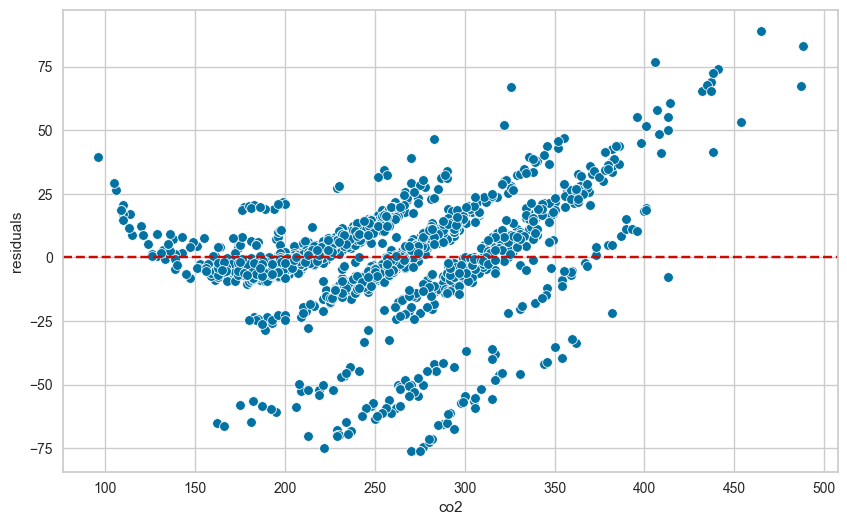

In [294]:
residuals = y_test - y_pred

plt.figure(figsize = (10,6))
sns.scatterplot(x = y_test, y = residuals) #-residuals
plt.axhline(y = 0, color ="r", linestyle = "--")
plt.ylabel("residuals");

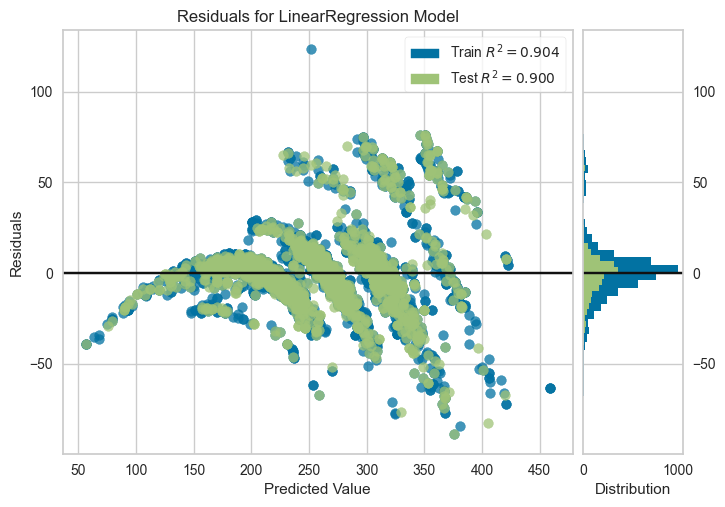

In [295]:
from yellowbrick.regressor import ResidualsPlot


model = LinearRegression()
visualizer = ResidualsPlot(model, force_model=True) 

visualizer.fit(X_train, y_train) 
visualizer.score(X_test, y_test)  
visualizer.show();                   # Finalize and render the figure

The residual plot indicates that the linear regression model has good performance, with ( R^2 ) values of 0.904 for the training set and 0.900 for the test set.

Most residuals are close to zero, indicating accurate predictions.

However, there are systematic errors as residuals increase with predicted values, suggesting the model may be biased for higher values.

Additionally, the spread of residuals indicates the variance of errors is not constant. This suggests potential areas for model improvement.

### Evaluating: Prediction Error for LinearRegression

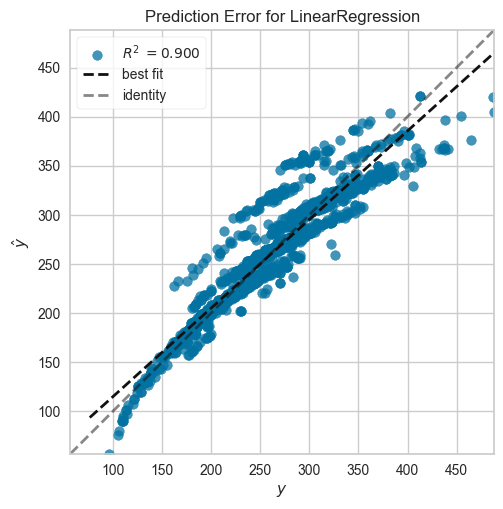

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [296]:
from yellowbrick.regressor import PredictionError

model = LinearRegression()

visualizer = PredictionError(model, force_model=True) 
visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show()          

This graph shows the prediction error for a linear regression model with an ( R^2 ) value of 0.900, indicating that 90% of the variance in the target variable is explained by the model.

The points are closely aligned with the best fit line, suggesting accurate predictions.

However, there is a slight deviation from the identity line, especially at higher values, indicating that the model may slightly underpredict or overpredict in certain ranges.

Overall, the model performs well with a high degree of accuracy.

### 2.3. Polynomial Features

In [297]:
from sklearn.preprocessing import PolynomialFeatures

def poly(d):
    
    train_rmse_errors = []
    test_rmse_errors = []
    number_of_features = []
    
    for i in range(1, d):
        polynomial_converter = PolynomialFeatures(degree = i, include_bias =False) 
        poly_features = polynomial_converter.fit_transform(X)                      
        
        X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
        
        model = LinearRegression(fit_intercept=True)
        model.fit(X_train, y_train)
        
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_RMSE = np.sqrt(mean_squared_error(y_train,train_pred))
        test_RMSE = np.sqrt(mean_squared_error(y_test,test_pred))
        
        train_rmse_errors.append(train_RMSE)
        test_rmse_errors.append(test_RMSE)
        
        number_of_features.append(poly_features.shape[1])

        return pd.DataFrame({"train_rmse_errors": train_rmse_errors, "test_rmse_errors":test_rmse_errors, 
                         "number of features":number_of_features}, index=range(1,d))

In [298]:
poly(8)

# The poly(8) function creates polynomial regression models of degrees 1 to 8, 
# evaluates their training and test RMSE, and returns a DataFrame summarizing these errors and 
# the number of features used at each degree.

,train_rmse_errors,test_rmse_errors,number of features
1,18.314047,18.08742,4
2,18.314047,18.08742,4
3,18.314047,18.08742,4
4,18.314047,18.08742,4
5,18.314047,18.08742,4
6,18.314047,18.08742,4
7,18.314047,18.08742,4


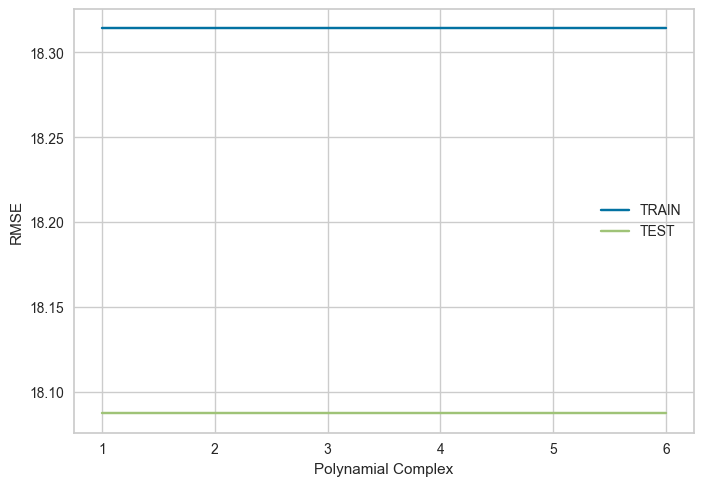

In [299]:
plt.plot(range(1,7), poly(7)["train_rmse_errors"], label = "TRAIN")
plt.plot(range(1,7), poly(7)["test_rmse_errors"], label = "TEST")
plt.xlabel("Polynamial Complex")
plt.ylabel("RMSE")
plt.legend()
plt.show()

In [300]:
# Selected degree=4

poly_converter = PolynomialFeatures(degree = 4, include_bias=False)

In [301]:
# Poly linear model

poly_lin_reg = LinearRegression()

In [302]:
X_train, X_test, y_train, y_test = train_test_split(poly_converter.fit_transform(X), y,
                                                    test_size = 0.2, random_state = 42)

In [303]:
poly_lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [304]:
y_train_pred = poly_lin_reg.predict(X_train)
y_pred = poly_lin_reg.predict(X_test)

#Evaluating the Model
poly_mlr_score = train_val(y_train, y_train_pred, y_test, y_pred, "poly(4)")
poly_mlr_score

,poly(4)_train,poly(4)_test
R2,0.953385,0.947646
mae,6.042713,6.426362
mse,159.355150,180.078849
rmse,12.623595,13.419346


#### Comparison of Multiple Linear & Poly Multiple Linear Regression

In [305]:

result = pd.concat([mlr_score, poly_mlr_score], axis=1)
result

,multi_train,multi_test,poly(4)_train,poly(4)_test
R2,0.903877,0.900108,0.953385,0.947646
mae,11.436689,11.514614,6.042713,6.426362
mse,330.829164,337.406607,159.355150,180.078849
rmse,18.188710,18.368631,12.623595,13.419346


The polynomial regression model (degree 4) performs better than the multiple linear regression model, achieving higher ( R^2 ) values

and lower MAE, MSE, and RMSE on both training and test sets, indicating better overall performance and accuracy.

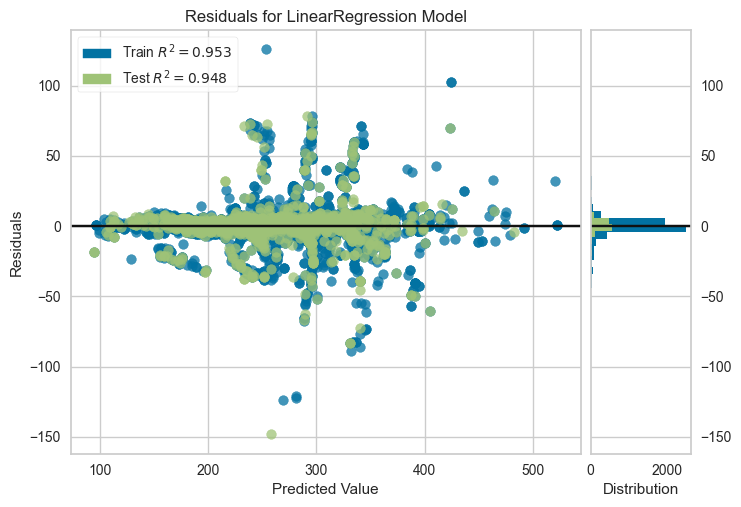

In [306]:
# Distributions of Poly_Multi Regression Residuals

poly_lin_reg = LinearRegression()
visualizer = ResidualsPlot(poly_lin_reg, force_model=True)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show();

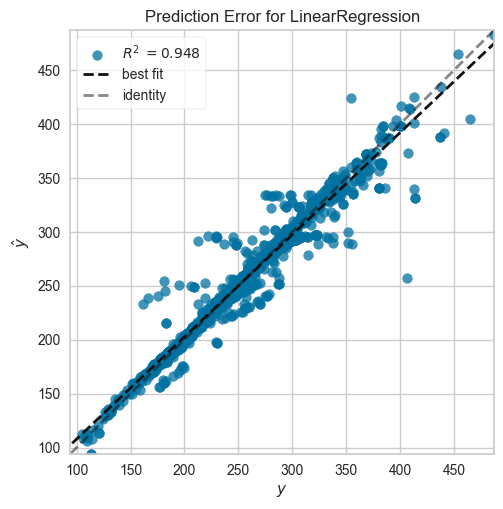

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [307]:
# Prediction Error for Poly_Multi LinearRegression

poly_lin_reg = LinearRegression()
visualizer = PredictionError(poly_lin_reg, force_model=True)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

### 2.4. Scaling the Data

In [308]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# StandardScaler

scaler = StandardScaler()
X_train.shape
(5908, 69)
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [309]:
X_train_scaled = scaler.transform(X_train)
X_train_scaled 

array([[-0.12149345,  0.20534188, -0.37681659, ...,  1.49112427,
         0.11090642, -0.1077625 ],
       [ 0.6141664 ,  0.20534188,  0.59257065, ..., -0.88383211,
        -0.7146818 , -0.4535469 ],
       [-0.12149345,  0.20534188,  0.24636092, ..., -0.45682398,
        -0.50862809, -0.38225914],
       ...,
       [ 0.24633648,  0.20534188, -0.20371173, ..., -0.45682398,
        -0.17471027, -0.2363027 ],
       [-0.48932338, -0.88513888, -0.82688924, ...,  0.46538028,
         0.6363709 ,  0.24212651],
       [ 0.6141664 ,  1.29582264,  0.31560287, ...,  1.02340697,
        -0.48713916, -0.38225914]], shape=(5908, 69))

In [310]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled 

array([[-0.12149345,  0.20534188, -0.03060686, ...,  0.34185348,
        -0.27672051, -0.29073711],
       [ 0.90843035,  1.29582264,  1.2849901 , ..., -0.91425102,
        -0.98206772, -0.52952408],
       [ 2.23261809,  1.29582264,  1.04264329, ..., -0.70108997,
        -0.89522984, -0.50782853],
       ...,
       [-1.29854922, -0.88513888, -1.10385702, ..., -0.45682398,
         1.06274987,  0.60302082],
       [ 0.24633648,  0.20534188, -0.27295367, ...,  1.02340697,
        -0.02542564, -0.17547199],
       [-0.85715331, -0.88513888, -0.96537313, ..., -1.06618224,
         0.73923453,  0.35208087]], shape=(1477, 69))

In [311]:
pd.DataFrame(X_train_scaled).agg(['mean','std']).round(2)

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
mean,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,...,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [312]:
pd.DataFrame(X_test_scaled).agg(['mean','std']).round(2) 

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
mean,-0.02,-0.02,-0.02,0.03,-0.02,-0.02,-0.02,-0.00,-0.02,-0.02,...,0.01,-0.02,-0.02,0.00,0.03,-0.01,-0.02,-0.03,0.03,0.03
std,0.98,0.98,1.01,1.03,0.97,0.97,0.98,0.98,0.97,0.98,...,1.02,0.94,0.98,1.01,1.06,0.97,1.00,0.98,1.04,1.05


## 2.5. Regularization

### 2.5.1. Ridge Regression

In [313]:
# Set the Ridge Regression Model

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1, random_state=42) # default alpha=1
# Fit the model

ridge_model.fit(X_train_scaled, y_train) 

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42


Ridge regression, or L2 regularization, is a technique used to improve linear regression models by reducing overfitting and handling multicollinearity.

In [314]:
# Prediction

y_pred = ridge_model.predict(X_test_scaled)        
y_train_pred = ridge_model.predict(X_train_scaled)


In [315]:
ridge_score = train_val(y_train, y_train_pred, y_test, y_pred, "ridge") 
ridge_score

,ridge_train,ridge_test
R2,0.936997,0.927938
mae,7.652171,8.404607
mse,215.378640,247.865625
rmse,14.675784,15.743749


In [316]:
ridge_model.coef_[:20]

array([ 23.53473429,  21.81177981,  36.25291809, -48.15273428,
         9.39307922, -20.15183773, -11.79747111,  -8.44492693,
        22.84914611,  21.24143961, -45.89679452, -46.50500418,
         1.95549588,  24.56310833,  11.56138468,  -8.88385905,
        11.4720219 ,   2.99571656,  -2.67187073, -29.49343799])

In [317]:
result = pd.concat([result, ridge_score], axis=1)
result

,multi_train,multi_test,poly(4)_train,poly(4)_test,ridge_train,ridge_test
R2,0.903877,0.900108,0.953385,0.947646,0.936997,0.927938
mae,11.436689,11.514614,6.042713,6.426362,7.652171,8.404607
mse,330.829164,337.406607,159.355150,180.078849,215.378640,247.865625
rmse,18.188710,18.368631,12.623595,13.419346,14.675784,15.743749


#### Cross Validation for Ridge with Alpha=1¶

In [318]:

model = Ridge(alpha=1)
scores = cross_validate(model, X_train_scaled, y_train,
                    scoring=['r2', 'neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'], 
                        cv=10, return_train_score=True)

In [319]:
scores = pd.DataFrame(scores, index = range(1, 11))
scores.iloc[:,2:].mean()

test_r2                                0.935583
train_r2                               0.936798
test_neg_mean_absolute_error          -7.741835
train_neg_mean_absolute_error         -7.687446
test_neg_mean_squared_error         -219.792111
train_neg_mean_squared_error        -216.053887
test_neg_root_mean_squared_error     -14.782462
train_neg_root_mean_squared_error    -14.698160
dtype: float64

In [320]:
ridgeCV_score = train_val(y_train, y_train_pred, y_test, y_pred, "ridgeCV")
ridgeCV_score

,ridgeCV_train,ridgeCV_test
R2,0.936997,0.927938
mae,7.652171,8.404607
mse,215.378640,247.865625
rmse,14.675784,15.743749


In [321]:
rm = Ridge(alpha=1).fit(X_train_scaled, y_train) 
rm.coef_

array([ 23.53473429,  21.81177981,  36.25291809, -48.15273428,
         9.39307922, -20.15183773, -11.79747111,  -8.44492693,
        22.84914611,  21.24143961, -45.89679452, -46.50500418,
         1.95549588,  24.56310833,  11.56138468,  -8.88385905,
        11.4720219 ,   2.99571656,  -2.67187073, -29.49343799,
       -25.92919118, -55.00731809,  32.57263268, -18.88823925,
        18.03713269,  28.127431  , -10.13832475, -18.82012788,
        35.17502176,  13.39583868, -61.73947535,  28.46289381,
       -44.73051695,  41.32117707, -30.79311153,  -8.82004599,
        66.10510349, -15.66256156,   2.9000786 ,   2.8575353 ,
       -13.17019181,  42.10532967,  14.22162041,   6.11491563,
        -1.01654173, -10.0296938 ,  -6.06762709, -32.36687191,
       -13.02702283,   1.04328498, -11.22597824, -12.41801012,
        12.9786839 ,  10.68898143, -26.69883855,  14.54118349,
        -7.1486499 ,  12.55756406,  31.1607279 ,   9.71332932,
        -2.45418754,  22.74877625, -16.18768068,  40.42

In [322]:
rm_df = pd.DataFrame(ridge_model.coef_,  columns = ["ridge_coef_1"])
rm_df

,ridge_coef_1
0,23.534734
1,21.811780
2,36.252918
3,-48.152734
4,9.393079
...,...
64,75.149177
65,-57.579683
66,1.148651
67,25.902982


#### 2.5.1.1. GridSearchCV for Ridge; Choosing best alpha value

In [323]:

from sklearn.model_selection import GridSearchCV
alpha_space = np.linspace(0.01, 1, 50)
alpha_space

array([0.01      , 0.03020408, 0.05040816, 0.07061224, 0.09081633,
       0.11102041, 0.13122449, 0.15142857, 0.17163265, 0.19183673,
       0.21204082, 0.2322449 , 0.25244898, 0.27265306, 0.29285714,
       0.31306122, 0.33326531, 0.35346939, 0.37367347, 0.39387755,
       0.41408163, 0.43428571, 0.4544898 , 0.47469388, 0.49489796,
       0.51510204, 0.53530612, 0.5555102 , 0.57571429, 0.59591837,
       0.61612245, 0.63632653, 0.65653061, 0.67673469, 0.69693878,
       0.71714286, 0.73734694, 0.75755102, 0.7777551 , 0.79795918,
       0.81816327, 0.83836735, 0.85857143, 0.87877551, 0.89897959,
       0.91918367, 0.93938776, 0.95959184, 0.97979592, 1.        ])

In [324]:
ridge_model = Ridge()
param_grid = {"alpha":alpha_space}

In [325]:
grid_ridge = GridSearchCV(estimator=ridge_model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          verbose=1,
                          return_train_score=True)

In [326]:
grid_ridge.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 50 candidates, totalling 500 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': array([0.01 ..., 1. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candid

In [327]:
grid_ridge.best_params_

{'alpha': np.float64(0.01)}

In [328]:
grid_ridge.best_index_


np.int64(0)

In [329]:
pd.DataFrame(grid_ridge.cv_results_).loc[0, ["mean_test_score", "mean_train_score"]]

mean_test_score    -13.999045
mean_train_score   -13.820160
Name: 0, dtype: float64

In [330]:
y_pred = grid_ridge.predict(X_test_scaled)
y_train_pred = grid_ridge.predict(X_train_scaled)

In [331]:
ridgeGrid_score = train_val(y_train, y_train_pred, y_test, y_pred, "ridgeGrid")
ridgeGrid_score

,ridgeGrid_train,ridgeGrid_test
R2,0.944163,0.936900
mae,7.015601,7.623278
mse,190.880188,217.040191
rmse,13.815940,14.732284


In [332]:
pd.concat([ridge_score, ridgeGrid_score], axis=1)

,ridge_train,ridge_test,ridgeGrid_train,ridgeGrid_test
R2,0.936997,0.927938,0.944163,0.936900
mae,7.652171,8.404607,7.015601,7.623278
mse,215.378640,247.865625,190.880188,217.040191
rmse,14.675784,15.743749,13.815940,14.732284


In [333]:
rgm = Ridge(alpha=0.01).fit(X_train_scaled, y_train) 
rgm.coef_

array([ 148.39183847,  -75.53931266,    1.8907318 ,  -39.20256684,
         80.34306174, -144.40626877,  173.68518904, -168.78894201,
        150.97509802,   11.5696862 , -102.97575086, -294.03955489,
        -33.72089149,  158.21866653, -320.35271221, -127.63244597,
        246.17253526,   -1.27365442,  -10.75809908, -247.52584336,
        -82.61894915,  -93.47045643,  271.25979231,   92.3647918 ,
        128.09209234,  195.27977512,  -81.51564514,  -36.46598892,
        144.61309797,  197.14778858,   17.45336923,  231.29931065,
       -170.15034684, -199.58119976, -210.87517604,  228.6001676 ,
        140.85750561,  171.97473875,  112.84838429,  -43.66048511,
        137.25102882,  627.41773032, -249.20137555,  -54.64930189,
        -37.3852035 , -233.61726158,  133.66930397, -166.89405254,
       -348.29371001,  102.16266909, -682.52353328,   76.31480967,
        -43.62101857,  -30.06120575,  -49.09926041,  -70.80371801,
       -121.43848889,  214.72161564,   44.60313191,   31.98253

In [334]:
rgm_df = pd.DataFrame(rgm.coef_,  columns = ["ridge_coef_0.01"])
rgm_df

,ridge_coef_0.01
0,148.391838
1,-75.539313
2,1.890732
3,-39.202567
4,80.343062
...,...
64,352.841758
65,-272.189742
66,33.830738
67,172.500921


In [335]:
pd.concat([rm_df, rgm_df], axis = 1)

,ridge_coef_1,ridge_coef_0.01
0,23.534734,148.391838
1,21.811780,-75.539313
2,36.252918,1.890732
3,-48.152734,-39.202567
4,9.393079,80.343062
...,...,...
64,75.149177,352.841758
65,-57.579683,-272.189742
66,1.148651,33.830738
67,25.902982,172.500921


### 2.5.2. Lasso Regression

In [336]:
from sklearn.linear_model import Lasso

In [337]:
# Set the Lasso Regression Model

lasso_model = Lasso(alpha=1)

In [338]:
# Fit the Model

lasso_model = lasso_model.fit(X_train_scaled, y_train)
lasso_model

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [339]:
y_pred = lasso_model.predict(X_test_scaled)
y_train_pred = lasso_model.predict(X_train_scaled)

In [340]:
ls_score = train_val(y_train, y_train_pred, y_test, y_pred, "lasso")
ls_score

,lasso_train,lasso_test
R2,0.908211,0.903149
mae,11.471661,11.815889
mse,313.786812,333.132733
rmse,17.714029,18.251924


In [341]:
lasso_model.coef_

array([  0.        ,   0.        ,   0.        , -31.55638666,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  15.41126594,  -0.        ,   0.        ,
         0.        ,  -0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   3.90259382,  -0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  -0.        ,  -0.        ,   0.        ,
        -0.        ,   0.        ,   0.        ,   0.        ,
         4.32641728,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,  -0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  -0.        ,   0.        ,   0.        ,
         0.        ,  -0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,  -0.        ,
         0.        ,   3.53742748,  -0.        ,   0.  

In [342]:
pd.concat([ridge_score, ridgeGrid_score, ls_score], axis=1)

,ridge_train,ridge_test,ridgeGrid_train,ridgeGrid_test,lasso_train,lasso_test
R2,0.936997,0.927938,0.944163,0.936900,0.908211,0.903149
mae,7.652171,8.404607,7.015601,7.623278,11.471661,11.815889
mse,215.378640,247.865625,190.880188,217.040191,313.786812,333.132733
rmse,14.675784,15.743749,13.815940,14.732284,17.714029,18.251924


In [343]:
lsm_df = pd.DataFrame(lasso_model.coef_, columns = ["lasso_coef_1"])

In [344]:
pd.concat([rm_df, rgm_df, lsm_df], axis = 1)

,ridge_coef_1,ridge_coef_0.01,lasso_coef_1
0,23.534734,148.391838,0.000000
1,21.811780,-75.539313,0.000000
2,36.252918,1.890732,0.000000
3,-48.152734,-39.202567,-31.556387
4,9.393079,80.343062,0.000000
...,...,...,...
64,75.149177,352.841758,-0.000000
65,-57.579683,-272.189742,0.000000
66,1.148651,33.830738,0.000000
67,25.902982,172.500921,-0.000000


### 2.5.2.1. GridSearchCV for Lasso; Choosing best alpha value

In [345]:
#Set the Lasso model

lasso_model = Lasso()

In [346]:
param_grid = {"alpha":alpha_space} #defined above

grid_lasso = GridSearchCV(estimator=lasso_model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=5,
                          verbose=1,
                          return_train_score=True)

In [347]:
# Fit the gridS Lasso Model

grid_lasso.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': array([0.01 ..., 1. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candida

In [348]:
grid_lasso.best_params_

{'alpha': np.float64(0.01)}

In [350]:
grid_lasso.best_index_

np.int64(0)

In [349]:
pd.DataFrame(grid_lasso.cv_results_).loc[0, ["mean_test_score", "mean_train_score"]]


mean_test_score    -15.409405
mean_train_score   -15.296438
Name: 0, dtype: float64

In [351]:
grid_lasso.best_score_

np.float64(-15.40940544736518)

In [352]:
lsm = Lasso(alpha=0.01).fit(X_train_scaled, y_train) 
lsm.coef_

array([ 3.93142732e+01,  2.10912481e+01,  1.14983007e+01, -2.53020981e+01,
       -2.27897244e+01, -1.12054793e+01, -1.09530392e+01, -4.93984805e+00,
        1.71996540e+01,  0.00000000e+00, -6.63218532e+00, -2.34753709e+01,
        3.33849133e+00,  0.00000000e+00,  1.52022208e+01,  0.00000000e+00,
        0.00000000e+00,  1.85606738e-01,  0.00000000e+00, -2.58258572e+00,
       -2.21179175e+00, -9.78175881e+00,  5.93328094e+00, -3.45177471e+00,
        5.71666927e+00,  8.34475432e+00, -0.00000000e+00, -4.71000807e+00,
        9.55470786e+00,  0.00000000e+00, -2.58754254e+01,  2.66309706e+01,
       -1.54022343e+01,  4.21110401e+01, -3.57094223e+00, -3.81286016e+00,
        2.19816905e+01, -3.36639023e+00, -2.44340158e+01,  5.80324585e-01,
       -0.00000000e+00,  2.13417112e+01,  0.00000000e+00, -0.00000000e+00,
       -1.63854747e+01, -0.00000000e+00, -2.47907933e+00, -0.00000000e+00,
       -0.00000000e+00, -8.65255730e+00,  7.38152165e+00, -1.30119602e+00,
       -1.85016334e+00,  

In [353]:
lgm_df = pd.DataFrame(lsm.coef_, columns=["lasso_coef_0.01"])
pd.concat([rm_df, rgm_df, lsm_df, lgm_df], axis = 1)

,ridge_coef_1,ridge_coef_0.01,lasso_coef_1,lasso_coef_0.01
0,23.534734,148.391838,0.000000,39.314273
1,21.811780,-75.539313,0.000000,21.091248
2,36.252918,1.890732,0.000000,11.498301
3,-48.152734,-39.202567,-31.556387,-25.302098
4,9.393079,80.343062,0.000000,-22.789724
...,...,...,...,...
64,75.149177,352.841758,-0.000000,17.304058
65,-57.579683,-272.189742,0.000000,-36.806642
66,1.148651,33.830738,0.000000,0.000000
67,25.902982,172.500921,-0.000000,-22.835374


In [354]:
# Prediction

y_pred = grid_lasso.predict(X_test_scaled)
y_train_pred = grid_lasso.predict(X_train_scaled)


In [355]:
lsg_score = train_val(y_train, y_train_pred, y_test, y_pred, "grid_lasso")
lsg_score

,grid_lasso_train,grid_lasso_test
R2,0.931439,0.923899
mae,8.526906,9.113804
mse,234.378526,261.758631
rmse,15.309426,16.178956


In [356]:
pd.concat([ridge_score, ridgeGrid_score, ls_score, lsg_score], axis=1)

,ridge_train,ridge_test,ridgeGrid_train,ridgeGrid_test,lasso_train,lasso_test,grid_lasso_train,grid_lasso_test
R2,0.936997,0.927938,0.944163,0.936900,0.908211,0.903149,0.931439,0.923899
mae,7.652171,8.404607,7.015601,7.623278,11.471661,11.815889,8.526906,9.113804
mse,215.378640,247.865625,190.880188,217.040191,313.786812,333.132733,234.378526,261.758631
rmse,14.675784,15.743749,13.815940,14.732284,17.714029,18.251924,15.309426,16.178956


### 2.6. Final Model and Prediction

#### Model

In [357]:
# Scale the Data

final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(poly_converter.fit_transform(X))
# Set the Final Model

final_model = Lasso(alpha=0.01)  #grid_lasso (Lasso model built over 28 features with our best alpha value )

# Fit the Final Model

final_model.fit(X_scaled, y)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [358]:
# Prediction of the Final Model

final_model.predict(X_scaled)

array([202.32031288, 226.03676396, 129.64073402, ..., 234.05166746,
       229.09360749, 238.89697646], shape=(7385,))

In [359]:
final_model.coef_

array([ 36.72826234,  22.89748574,   8.57593383, -25.15151208,
       -21.80654934, -11.32249581,  -9.90626373,  -4.29136716,
        15.90883766,   0.        ,  -7.12051605, -21.17772776,
         3.43262021,  -0.55717158,  16.5599249 ,   0.        ,
         0.        ,   0.        ,  -1.2027637 ,  -3.82215834,
        -2.8531007 ,  -9.16232562,   5.88947659,  -2.72866572,
         4.71066454,  10.77547276,  -0.        ,  -1.09327297,
         7.95584525,   0.        , -27.45868298,  25.01927537,
       -15.37992859,  38.6166295 ,  -1.03958338,  -3.18606714,
        19.57316841,  -4.68043557, -23.86059701,   0.        ,
        -0.10805156,  18.68248114,   0.        ,  -0.        ,
       -15.39914546,  -0.        ,  -2.98029356,  -0.        ,
        -0.        ,  -8.59617613,   6.66861927,   0.        ,
        -0.95286808,   9.7364982 ,  -0.        ,  15.99084398,
        -1.48506904,   0.77492297,   8.60489526,  -6.80889799,
         0.        ,   0.        ,  -6.32833095,  10.65

In [360]:
final_model.intercept_

np.float64(250.58469871360683)

In [361]:
X.head()

,engine_size,cylinders,fuel_cons_comb,fuel_cons_comb_mpg
0,2.0,4,8.5,33
1,2.4,4,9.6,29
2,1.5,4,5.9,48
3,3.5,6,11.1,25
4,3.5,6,10.6,27


### Predicting

In [362]:

new_data = [[3.5, 12.1, 8.7, 10.6]]
new_data

[[3.5, 12.1, 8.7, 10.6]]

In [363]:
poly_sample = poly_converter.transform(new_data)
poly_sample

array([[3.50000000e+00, 1.21000000e+01, 8.70000000e+00, 1.06000000e+01,
        1.22500000e+01, 4.23500000e+01, 3.04500000e+01, 3.71000000e+01,
        1.46410000e+02, 1.05270000e+02, 1.28260000e+02, 7.56900000e+01,
        9.22200000e+01, 1.12360000e+02, 4.28750000e+01, 1.48225000e+02,
        1.06575000e+02, 1.29850000e+02, 5.12435000e+02, 3.68445000e+02,
        4.48910000e+02, 2.64915000e+02, 3.22770000e+02, 3.93260000e+02,
        1.77156100e+03, 1.27376700e+03, 1.55194600e+03, 9.15849000e+02,
        1.11586200e+03, 1.35955600e+03, 6.58503000e+02, 8.02314000e+02,
        9.77532000e+02, 1.19101600e+03, 1.50062500e+02, 5.18787500e+02,
        3.73012500e+02, 4.54475000e+02, 1.79352250e+03, 1.28955750e+03,
        1.57118500e+03, 9.27202500e+02, 1.12969500e+03, 1.37641000e+03,
        6.20046350e+03, 4.45818450e+03, 5.43181100e+03, 3.20547150e+03,
        3.90551700e+03, 4.75844600e+03, 2.30476050e+03, 2.80809900e+03,
        3.42136200e+03, 4.16855600e+03, 2.14358881e+04, 1.541258

In [364]:
scaled_sample = final_scaler.transform(poly_sample)
scaled_sample

array([[ 2.51043221e-01,  3.54722175e+00, -7.86592975e-01,
        -2.33449629e+00,  4.20258727e-02,  1.45294115e+00,
        -2.90439294e-01, -2.07731384e+00,  4.50420741e+00,
         1.03559282e+00, -6.02276288e-01, -7.35575271e-01,
        -5.86081736e+01, -1.51383251e+00, -1.21983313e-01,
         6.42965545e-01, -2.74015663e-01, -7.88482810e-01,
         2.25843619e+00,  4.34757532e-01, -9.07753134e-02,
        -4.63284330e-01, -1.48898696e+00, -2.43349716e+00,
         5.31668308e+00,  1.94600141e+00,  1.74285042e+00,
         1.28123365e-01, -9.07934976e-01, -1.71633442e+00,
        -6.40070374e-01, -2.80600957e+00, -3.31347594e+00,
        -9.69374967e-01, -2.24618757e-01,  2.00279972e-01,
        -3.05132015e-01, -5.30763799e-01,  1.09483757e+00,
         9.52080499e-02, -1.39833961e-01, -3.96621308e-01,
        -7.63124967e-01, -1.51617548e+00,  2.77494239e+00,
         9.31811464e-01,  8.04691124e-01, -4.98680683e-02,
        -4.03703334e-01, -1.41414686e+00, -4.77209892e-0

In [ ]:
final_model.predict(scaled_sample)

array([331.8565249])

In [371]:
import os
import joblib

folder_path = "./models/co2_emission_prediction_model.pkl"

# 2. Extract the directory name and create it if missing
os.makedirs(os.path.dirname(folder_path), exist_ok=True)
# Save the model to a file
joblib.dump(final_model, './models/co2_emission_prediction_model.pkl')

# To load the model for future inferencing:
# loaded_model = joblib.load('polynomial_regression_model.joblib')


['./models/co2_emission_prediction_model.pkl']